Research question 

To what extent are municipalities able to achieve “green growth” (or post-growth?) in British Columbia, as measured by a decoupling of growth in wellbeing from the growth in transportation and utility GHG emissions? 

What inequities exist in the access of solar energy across B.C.? Do these inequities correlate with lower housing wellbeing index?

Scope 

Timeframe: 2012 – 2021 

Emissions scope: CO2e for utilities of residential and small and medium indistry, on-road transportation

In [56]:
#import libraries
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [57]:
#load the community emissions dataset as csv file
utility_emissions = pd.read_csv('../data/raw/utilities_new.csv')

#replace W's from emissions in wood with 0
utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'] = utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'].replace('W', 0)

# Display the first few rows of the utility emissions dataset
utility_emissions.head()

,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,CONNECTION_TOTAL,EMISSIONS NET IMPORTS (TCO2e),Unnamed: 12,Unnamed: 13,Unnamed: 14
0,2022,BC Hydro,11080,5909052,Abbotsford,1005909,ELEC,kWh,Res,538127235.5,48760,6187.602205,2022ELECkWh,NaN,NaN
1,2022,BC Hydro,11080,1005923,Alberni-Clayoquot,9000000,ELEC,kWh,Res,226116610.6,17311,2599.979236,2022ELECkWh,NaN,NaN
2,2022,BC Hydro,11080,2005923,Alberni-Clayoquot Unincorporated Areas,1005923,ELEC,kWh,Res,79348847.45,5601,912.3847875,2022ELECkWh,NaN,NaN
3,2022,BC Hydro,11080,5943008,Alert Bay,1005943,ELEC,kWh,Res,3775260.192,275,43.40945179,2022ELECkWh,NaN,NaN
4,2022,BC Hydro,11080,5915038,Anmore,1005915,ELEC,kWh,Res,14323873.26,773,164.7016243,2022ELECkWh,NaN,NaN


In [58]:
# load the transportation emissions dataset as csv file
transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')
transportation_emissions.head()


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_81693/1375076493.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')


,ORG_UNIT,ORG_NAME,ORG_PART,Year,Vehicle Type,Fuel Type,Vehicle Fuel Category,Policy Years Earned,Vehicle Kilometres Travelled,Letres Equivalents,Emissions tCO2e,Unnamed: 11
0,5909052,Abbotsford,1005909,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,1.00,11734.493600,5890.715786,8.010833,NaN
1,5915038,Anmore,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.89,9240.491799,4638.726883,6.308712,NaN
2,5933019,Ashcroft,1005933,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.76,7890.757042,3961.160035,5.388842,NaN
3,5915036,Belcarra,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.00,0.000000,0.000000,0.000000,NaN
4,2005951,Bulkley-Nechako Unincorporated Areas,1005951,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.11,1142.083256,573.325795,0.778630,NaN


In [59]:
#list of regional districts including typos in datasets
bc_regional_districts = [
    "Alberni-Clayoquot",
    "Bulkley-Nechako",
    "Capital",
    "Cariboo",
    "Central Coast",
    "Central Kootenay",
    "Central Okanagan",
    "Columbia-Shuswap",
    "Comox Valley",
    "Cowichan Valley",
    "East Kootenay",
    "Fraser Valley",
    "Fraser-Fort George",
    "Greater Vancouver",
    "Islands Trust",
    "Kitimat-Stikine",
    "Kootenay Boundary",
    "Metro-Vancouver",
    "Mount Waddington",
    "Nanaimo RD",
    "North Okanagan",
    "Northern Rockies RD",
    "Okanagan-Similkameen",
    "Peace River",
    "qathet",
    "Skeena-Queen Charlotte",
    "Squamish-Lillooet",
    "Stikine",
    "Sitkine",
    "Strathcona",
    "Sunshine Coast",
    "Thompson-Nicola"
]
#list of unincorporated areas
list_of_unincorporated_areas = [
    "Alberni-Clayoquot Unincorporated Areas",
    "Bulkley-Nechako Unincorporated Areas",
    "Capital Unincorporated Areas",
    "Cariboo Unincorporated Areas",
    "Central Coast Unincorporated Areas",
    "Central Kootenay Unincorporated Areas",
    "Central Okanagan Unincorporated Areas",
    "Columbia-Shuswap Unincorporated Areas",
    "Comox Valley Unincorporated Areas",
    "Comox Unincorporated Areas",
    "Cowichan Valley Unincorporated Areas",
    "East Kootenay Unincorporated Areas",
    "Fraser Valley Unincorporated Areas",
    "Fraser-Fort George Unincorporated Areas",
    "Greater Vancouver Unincorporated Areas",
    "Islands Trust Unincorporated Areas",
    "Kitimat-Stikine Unincorporated Areas",
    "Kootenay Boundary Unincorporated Areas",
    "Metro-Vancouver Unincorporated Areas",
    "Mount Waddington Unincorporated Areas",
    "Nanaimo Unincorporated Areas",
    "Northern Rockies Unincorporated Areas", #check if there are variations to this, like Northern Rockies Regional Municipality Unincorporated Areas
    "Skeena-Queen Charlotte Unincorporated Areas",
    "North Okanagan Unincorporated Areas",
    "Okanagan-Similkameen Unincorporated Areas",
    "Peace River Unincorporated Areas",
    "Powell River Unincorporated Areas",
    "qathet Unincorporated Areas",
    "Squamish-Lillooet Unincorporated Areas",
    "Stikine Unincorporated Areas",
    "Sitkine Unincorporated Areas",
    "Sunshine Coast Unincorporated Areas",
    "Strathcona Unincorporated Areas",
    "Thompson-Nicola Unincorporated Areas"
]
province = ["British Columbia"]

Indigenous= ["Sechelt IGD", "Sechelt Ind Gov Dist (Part-Powell River)", "Sechelt Ind Gov Dist"]

#four_std_dev_outliers = ["Warfield", "Elkford", "Burns Lake", "Kaslo", "Telkwa", "Highlands", "Invermere", "Squamish", "Burnaby"]

outliers_clustering = ["Comox", "Elkford", "Powell River"]

population_below_250 = ["Hazelton", "Lytton", "Silverton", "Wells", "Zeballos", "Tahsis"]

not_in_2006_cwb = ["Slocan", "Barriere", "Clearwater", "Sun Peaks Mountain Resort", "Sun Peaks Mountain", "West Kelowna",  "Northern Rockies", "Northern Rockies Regional Municipality" ,"Norther Rockies Regional Municipality",]

exclusions_list = (list_of_unincorporated_areas 
                                                  + bc_regional_districts 
                                                  + province 
                                                  + not_in_2006_cwb 
                                                  + population_below_250 
                                                  + Indigenous
                                                  + outliers_clustering
                                                  #+ four_std_dev_outliers
                                                  )

#list of years
years_transportation_co2 = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_buildings_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_waste_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

In [60]:
#select municipalities from the utility emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~utility_emissions['ORG_NAME'].isin(exclusions_list)
                                           
utility_df = utility_emissions[mask]
#print(utility_df['ORG_NAME'].unique())
#save the utility_df to a csv file in the data/processed folder
utility_df.to_csv(os.path.join('..','data','processed','municipalities_utility_emissions.csv'), index=False)
utility_df.head()

,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,CONNECTION_TOTAL,EMISSIONS NET IMPORTS (TCO2e),Unnamed: 12,Unnamed: 13,Unnamed: 14
0,2022,BC Hydro,11080,5909052,Abbotsford,1005909,ELEC,kWh,Res,538127235.5,48760,6187.602205,2022ELECkWh,NaN,NaN
3,2022,BC Hydro,11080,5943008,Alert Bay,1005943,ELEC,kWh,Res,3775260.192,275,43.40945179,2022ELECkWh,NaN,NaN
4,2022,BC Hydro,11080,5915038,Anmore,1005915,ELEC,kWh,Res,14323873.26,773,164.7016243,2022ELECkWh,NaN,NaN
5,2022,BC Hydro,11080,5937028,Armstrong,1005937,ELEC,kWh,Res,21935314.26,2408,252.2210175,2022ELECkWh,NaN,NaN
6,2022,BC Hydro,11080,5933019,Ashcroft,1005933,ELEC,kWh,Res,7649213.599,940,87.95371765,2022ELECkWh,NaN,NaN


In [61]:

# Remove commas from the values, then convert to numeric
utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = utility_df['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
#remove 'W' from the values and convert to numeric, filling NaN with 0
utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_df['EMISSIONS NET IMPORTS (TCO2e)'], errors='coerce').fillna(0)

# Remove commas from the values, then convert to numeric
utility_df['CONSUMPTION_TOTAL'] = utility_df['CONSUMPTION_TOTAL'].astype(str).str.replace(',', '')
#remove 'W' from the values and convert to numeric, filling NaN with 0
utility_df['CONSUMPTION_TOTAL'] = pd.to_numeric(utility_df['CONSUMPTION_TOTAL'], errors='coerce').fillna(0)


#correct norther rockies to northern rockies -> in the end it doesn't matter since I exclude this municipality
utility_df['ORG_NAME'] = utility_df['ORG_NAME'].str.replace('Norther Rockies Regional Municipality', 'Northern Rockies Regional Municipality')
utility_df['ORG_NAME'] = utility_df['ORG_NAME'].str.replace('Northern Rockies Regional Municipality', 'Northern Rockies')

#remove summerland's fortis electric values under "source" in utility_df but keep the city_of_summerland values
utility_df = utility_df[~((utility_df['ORG_NAME'] == 'Summerland') & (utility_df['SOURCE'] == 'Fortis Electric'))]

#replace BC Hydro residential electricity values for 2020 with 21533683 and csmi with 20119061 and estimate emissions
utility_df.loc[(utility_df['ORG_NAME']=="Tofino") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONSUMPTION_TOTAL'] = 21533683
utility_df.loc[(utility_df['ORG_NAME']=="Tofino") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONNECTION_TOTAL'] = 1315
utility_df.loc[(utility_df['ORG_NAME']=="Tofino") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'EMISSIONS NET IMPORTS (TOC2e)'] = 230

#replace Taylor's values for 2020 residential data and CSMI data
utility_df.loc[(utility_df['ORG_NAME']=="Taylor") & (utility_df['SOURCE']=="Pacific Northern Gas") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONSUMPTION_TOTAL'] = 56508
utility_df.loc[(utility_df['ORG_NAME']=="Taylor") & (utility_df['SOURCE']=="Pacific Northern Gas") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONNECTION_TOTAL'] = 528
utility_df.loc[(utility_df['ORG_NAME']=="Taylor") & (utility_df['SOURCE']=="Pacific Northern Gas") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'EMISSIONS NET IMPORTS (TOC2e)'] = 2845
utility_df.loc[(utility_df['ORG_NAME']=="Taylor") & (utility_df['SOURCE']=="Pacific Northern Gas") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="CSMI"), 'CONSUMPTION_TOTAL'] = 22756
utility_df.loc[(utility_df['ORG_NAME']=="Taylor") & (utility_df['SOURCE']=="Pacific Northern Gas") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="CSMI"), 'EMISSIONS NET IMPORTS (TOC2e)'] = 1146


utility_df.loc[(utility_df['ORG_NAME']=="Port Alberni") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONSUMPTION_TOTAL'] = 96371327 
utility_df.loc[(utility_df['ORG_NAME']=="Port Alberni") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'CONNECTION_TOTAL'] = 8739 
utility_df.loc[(utility_df['ORG_NAME']=="Port Alberni") & (utility_df['SOURCE']=="BC Hydro") & (utility_df["YEAR"]==2020) &(utility_df["SUB_SECTOR"]=="Res"), 'EMISSIONS NET IMPORTS (TOC2e)'] = 3775 


#drop all datapoints for 2022 in utility dataset since some of them had problems anyways
utility_df = utility_df[utility_df['YEAR'] != 2022]
#drop all "MIXED" in the utility dataset
utility_df = utility_df[utility_df['SUB_SECTOR'] != "MIXED"]




/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_81693/2334838542.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = utility_df['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_81693/2334838542.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_df['EMISSIONS NET IMPORTS (TCO2e)'], errors='coerce').fillna(0)
/

In [62]:
#count how many org names show up when we filter the ones that are within CSMI and supplied by fortis electric, fortis electric, and pacific northern gas
CSMI_fortis_pcng = utility_df[
    (utility_df["SUB_SECTOR"] == "CSMI") & 
    (utility_df["SOURCE"].isin(["Fortis Electric", "Fortis Gas", "Pacific Northern Gas"]))
]

In [63]:
print(CSMI_fortis_pcng["ORG_NAME"].nunique())


116


In [64]:
# List of sources to exclude from interpolation for the year 2013
excluded_sources = [
    'BC Hydro', 
    'Fortis Electric', 
    'Fortis Gas', 
    'Pacific Northern Gas',
    'Estimate-Heating Oil',
    'Estimate-Propane',
    'Estimate-Wood'
]

df = utility_df.copy()
# Get sources that need interpolation
sources_to_interpolate = df[~df['SOURCE'].isin(excluded_sources)]['SOURCE'].unique()

# List to store new interpolated rows
interpolated_rows = []

# Iterate through each source that needs interpolation
for source in sources_to_interpolate:
    # Get data for this source in 2012 and 2014
    data_2012 = df[(df['YEAR'] == 2012) & (df['SOURCE'] == source)]
    data_2014 = df[(df['YEAR'] == 2014) & (df['SOURCE'] == source)]
    
    # Get unique ORG_NAMEs that exist in both 2012 and 2014
    org_names_2012 = set(data_2012['ORG_NAME'].unique())
    org_names_2014 = set(data_2014['ORG_NAME'].unique())
    common_org_names = org_names_2012.intersection(org_names_2014)
    
    # For each ORG_NAME
    for org_name in common_org_names:
        # Get data for this ORG_NAME
        org_data_2012 = data_2012[data_2012['ORG_NAME'] == org_name]
        org_data_2014 = data_2014[data_2014['ORG_NAME'] == org_name]
        
        # Get unique ENERGY_TYPEs for this ORG_NAME in both years
        energy_types_2012 = set(org_data_2012['ENERGY_TYPE'].unique())
        energy_types_2014 = set(org_data_2014['ENERGY_TYPE'].unique())
        common_energy_types = energy_types_2012.intersection(energy_types_2014)
        
        # For each ENERGY_TYPE
        for energy_type in common_energy_types:
            # Get data for this ENERGY_TYPE
            energy_data_2012 = org_data_2012[org_data_2012['ENERGY_TYPE'] == energy_type]
            energy_data_2014 = org_data_2014[org_data_2014['ENERGY_TYPE'] == energy_type]
            
            # Get unique SUB_SECTORs for this ENERGY_TYPE in both years
            sub_sectors_2012 = set(energy_data_2012['SUB_SECTOR'].unique())
            sub_sectors_2014 = set(energy_data_2014['SUB_SECTOR'].unique())
            common_sub_sectors = sub_sectors_2012.intersection(sub_sectors_2014)
            
            # For each SUB_SECTOR
            for sub_sector in common_sub_sectors:
                # Get the specific rows for 2012 and 2014
                row_2012 = energy_data_2012[energy_data_2012['SUB_SECTOR'] == sub_sector]
                row_2014 = energy_data_2014[energy_data_2014['SUB_SECTOR'] == sub_sector]
                
                if not row_2012.empty and not row_2014.empty:
                    # Take the first row if there are multiple (shouldn't happen with unique combination)
                    row_2012 = row_2012.iloc[0]
                    row_2014 = row_2014.iloc[0]
                    
                    # Get values for interpolation
                    consumption_2012 = float(row_2012['CONSUMPTION_TOTAL']) if pd.notna(row_2012['CONSUMPTION_TOTAL']) else 0
                    consumption_2014 = float(row_2014['CONSUMPTION_TOTAL']) if pd.notna(row_2014['CONSUMPTION_TOTAL']) else 0
                    
                    connection_2012 = float(row_2012['CONNECTION_TOTAL']) if pd.notna(row_2012['CONNECTION_TOTAL']) else 0
                    connection_2014 = float(row_2014['CONNECTION_TOTAL']) if pd.notna(row_2014['CONNECTION_TOTAL']) else 0
                    
                    emissions_2012 = float(row_2012['EMISSIONS NET IMPORTS (TCO2e)']) if pd.notna(row_2012['EMISSIONS NET IMPORTS (TCO2e)']) else 0
                    emissions_2014 = float(row_2014['EMISSIONS NET IMPORTS (TCO2e)']) if pd.notna(row_2014['EMISSIONS NET IMPORTS (TCO2e)']) else 0
                    
                    # Calculate averages for interpolation
                    consumption_2013 = (consumption_2012 + consumption_2014) / 2
                    connection_2013 = (connection_2012 + connection_2014) / 2
                    emissions_2013 = (emissions_2012 + emissions_2014) / 2
                    
                    # Create new row for 2013
                    new_row = {
                        'YEAR': 2013,
                        'SOURCE': source,
                        'Data Source ID': '20122014',  # Symbolic value for interpolation
                        'ORG_UNIT': row_2012['ORG_UNIT'],  # Keep same ORG_UNIT
                        'ORG_NAME': org_name,
                        'ORG_PART': row_2012['ORG_PART'],  # Keep same ORG_PART
                        'ENERGY_TYPE': energy_type,
                        'ENERGY_UNIT': row_2012['ENERGY_UNIT'],  # Keep same ENERGY_UNIT
                        'SUB_SECTOR': sub_sector,
                        'CONSUMPTION_TOTAL': consumption_2013,
                        'CONNECTION_TOTAL': connection_2013,
                        'EMISSIONS NET IMPORTS (TCO2e)': emissions_2013
                    }
                    
                    interpolated_rows.append(new_row)


# Add interpolated rows to the dataframe
if interpolated_rows:
    df_interpolated = pd.DataFrame(interpolated_rows)
    utility_df = pd.concat([utility_df, df_interpolated], ignore_index=True)
    
    # Sort by year and other columns for better organization
    utility_df = utility_df.sort_values(['YEAR', 'SOURCE', 'ORG_NAME', 'ENERGY_TYPE']).reset_index(drop=True)
    
    print(f"Successfully added {len(interpolated_rows)} interpolated rows for 2013")
    print(f"\nSources interpolated: {sorted(set([row['SOURCE'] for row in interpolated_rows]))}")
    
    # Show sample of interpolated data
    print("\nSample of interpolated 2013 data:")
    sample_df = utility_df[(utility_df['YEAR'] == 2013) & (utility_df['Data Source ID'] == '20122014')].head(5)
    print(sample_df[['YEAR', 'SOURCE', 'ORG_NAME', 'ENERGY_TYPE', 'CONSUMPTION_TOTAL', 'CONNECTION_TOTAL', 'EMISSIONS NET IMPORTS (TCO2e)']])
else:
    print("No rows needed interpolation based on the criteria")

# Verify by checking a specific example
if interpolated_rows:
    # Pick first interpolated source for verification
    sample_source = interpolated_rows[0]['SOURCE']
    sample_org = interpolated_rows[0]['ORG_NAME']
    sample_energy = interpolated_rows[0]['ENERGY_TYPE']
    
    print(f"\nVerification for {sample_source}, {sample_org}, {sample_energy}:")
    verification_df = utility_df[
        (utility_df['SOURCE'] == sample_source) & 
        (utility_df['ORG_NAME'] == sample_org) & 
        (utility_df['ENERGY_TYPE'] == sample_energy) &
        (utility_df['YEAR'].isin([2012, 2013, 2014]))
    ]
    print(verification_df[['YEAR', 'CONSUMPTION_TOTAL', 'CONNECTION_TOTAL', 'EMISSIONS NET IMPORTS (TCO2e)']])

Successfully added 13 interpolated rows for 2013

Sources interpolated: ['Cal-gas', 'City of Grand Forks', 'City of Penticton ', 'City of Summerland ', 'Nelson Electric', 'New Westminster Electrical Utility', 'Port Alice Gas']

Sample of interpolated 2013 data:
      YEAR               SOURCE     ORG_NAME ENERGY_TYPE  CONSUMPTION_TOTAL  \
3168  2013              Cal-gas       Golden        PPRO             1341.0   
3169  2013  City of Grand Forks  Grand Forks        ELEC         18297239.5   
3170  2013  City of Grand Forks  Grand Forks        ELEC         20804040.5   
3171  2013   City of Penticton     Penticton        ELEC        185936070.0   
3172  2013   City of Penticton     Penticton        ELEC        157808290.0   

     CONNECTION_TOTAL  EMISSIONS NET IMPORTS (TCO2e)  
3168             24.0                      81.657514  
3169           1879.0                     463.659635  
3170            322.5                     531.354733  
3171          15446.5                    47

In [65]:
# Group by YEAR and ORG_NAME, summing the emissions
total_utility_emissions = utility_df.groupby(
    ['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()

#save to csv file in the data/processed folder
total_utility_emissions.to_csv(os.path.join('..','data','processed','total_utility_emissions.csv'), index=False)
total_utility_emissions.tail()


,YEAR,ORG_NAME,EMISSIONS NET IMPORTS (TCO2e)
1735,2021,Warfield,3222.315145
1736,2021,West Vancouver,138127.678209
1737,2021,Whistler,54430.956601
1738,2021,White Rock,41192.637901
1739,2021,Williams Lake,88545.047895


In [66]:
print ("\nTotal utility emissions for each community:")
# Display the total utility emissions for each community
print(total_utility_emissions)


Total utility emissions for each community:
      YEAR        ORG_NAME  EMISSIONS NET IMPORTS (TCO2e)
0     2007      Abbotsford                  369133.300024
1     2007       Alert Bay                     835.510099
2     2007          Anmore                    4442.247271
3     2007       Armstrong                   11999.055741
4     2007        Ashcroft                   14440.813090
...    ...             ...                            ...
1735  2021        Warfield                    3222.315145
1736  2021  West Vancouver                  138127.678209
1737  2021        Whistler                   54430.956601
1738  2021      White Rock                   41192.637901
1739  2021   Williams Lake                   88545.047895

[1740 rows x 3 columns]


In [67]:
#select municipalities from the transportation emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~transportation_emissions['ORG_NAME'].isin(exclusions_list)
transportation_df = transportation_emissions[mask]

#change names of communities to match the utility_df
# Greater Vancouver -> Metro Vancouver
# Sun Peaks Mountain -> Sun Peaks Mountain Resort
# Sechelt District Municipality -> Sechelt

transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({
    "Greater Vancouver": "Metro Vancouver",
    "Sun Peaks Mountain": "Sun Peaks Mountain Resort",
    "Sechelt District Municipality": "Sechelt",
    "Sechelt Ind Gov Dist (Part-Powell River)": "Sechelt IGD",
    "Sechelt Ind Gov Dist": "Sechelt IGD"
})
transportation_df.to_csv(os.path.join('..','data','processed','municipalities_transportation_emissions.csv'), index=False)
#transportation_df.head()
#print(transportation_df['ORG_NAME'].unique())

#drop all datapoints for 2022 in transportation dataset
transportation_df = transportation_df[transportation_df['Year'] != 2022]

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_81693/828340208.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({


In [68]:
#for each year and each community, calculate the total emissions for that community by summing the emissions for values in all vehicle fuel categories

# Group by 'YEAR' and 'ORG_NAME' and sum the emissions
total_transportation_emissions = transportation_df.groupby(['Year', 'ORG_NAME'], as_index=False)['Emissions tCO2e'].sum()

#save to csv file in the data/processed folder
total_transportation_emissions.to_csv(os.path.join('..','data','processed','total_transportation_emissions.csv'), index=False)

In [69]:
print("Unique organizations in total_emissions:")
#print(total_transportation_emissions['ORG_NAME'].unique())

Unique organizations in total_emissions:


In [70]:
print ("\nTotal transportation emissions for each community:")
# Display the total transportation emissions for each community
#total_emissions.head()
#print(total_transportation_emissions)


Total transportation emissions for each community:


In [71]:
transportation_emissions_communities_list = set(total_transportation_emissions['ORG_NAME'])
utility_emissions_communities_list = set(total_utility_emissions['ORG_NAME'])
# Find communities that are in transportation emissions but not in utility emissions
missing_communities = transportation_emissions_communities_list - utility_emissions_communities_list
print("\nCommunities in transportation emissions but not in utility emissions:")
print(missing_communities)
# Find communities that are in utility emissions but not in transportation emissions
missing_communities = utility_emissions_communities_list - transportation_emissions_communities_list
print("\nCommunities in utility emissions but not in transportation emissions:")
print(missing_communities)


Communities in transportation emissions but not in utility emissions:
set()

Communities in utility emissions but not in transportation emissions:
set()


In [72]:
#find outlier municipalities based on locations that have emissions/energy consumption for residential or for transportation percent change greater than X standard deviations from mean percent change year over year


In [73]:
#open CWB_2021 and CWB_2011 from the data folder/raw
# Load the dataset
cwb_2021 = pd.read_csv(os.path.join('..','data','raw','CWB_2021.csv'),encoding='latin-1')
cwb_2016 = pd.read_csv(os.path.join('..','data','raw','CWB_2016.csv'))
cwb_2011 = pd.read_csv(os.path.join('..','data','raw','CWB_2011.csv'),encoding='latin-1')
cwb_2006 = pd.read_csv(os.path.join('..','data','raw','CWB_2006.csv'),encoding='latin-1')
# Display the first few rows of each dataset
print("CWB_2021 dataset:")
print(cwb_2021.head())

print("\n CWB_2016_dataset:")
print(cwb_2016.head())

print("\n CWB_2011_dataset:")
print(cwb_2011.head())

print("\n CWB_2006_dataset:")
print(cwb_2006.head())

CWB_2021 dataset:
   CSD Code 2021             CSD Name 2021  Census Population 2021  \
0        1001101  Division No.  1, Subd. V                    55.0   
1        1001105       Portugal Cove South                    86.0   
2        1001113                 Trepassey                   405.0   
3        1001120               St. Shott's                    55.0   
4        1001124  Division No.  1, Subd. U                  1373.0   

   Income 2021  Education 2021  Housing 2021  Labour Force Activity 2021  \
0          NaN             NaN           NaN                         NaN   
1          NaN             NaN           NaN                         NaN   
2         76.0            48.0          97.0                        70.0   
3          NaN             NaN           NaN                         NaN   
4         81.0            63.0          98.0                        77.0   

   CWB 2021       Community Type 2021  
0       NaN  Non-Indigenous Community  
1      73.0  Non-Indigen

In [74]:
#replace the csd name "north vancouver" that has a csd code 5915046 in column one, to "north vancouver district municipality"
#replace the csd name "north vancouver" that has a csd code 5915051 in column one, to "north vancouver city"

# Replace 2021 North Vancouver entries based on CSD codes
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915046, 'CSD Name 2021'] = 'North Vancouver District'
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915051, 'CSD Name 2021'] = 'North Vancouver City'

# Replace 2016 North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915046, 'CSD Name 2016'] = 'North Vancouver District'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915051, 'CSD Name 2016'] = 'North Vancouver City'

# Replace 2011North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915046, 'CSD Name 2011'] = 'North Vancouver District'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915051, 'CSD Name 2011'] = 'North Vancouver City'

# Replace 2006 North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915046, 'CSD Name 2006'] = 'North Vancouver District'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915051, 'CSD Name 2006'] = 'North Vancouver City'


#rename sun peaks mountain to sun peaks mountain resort in the cwb data
cwb_2021['CSD Name 2021'] = cwb_2021['CSD Name 2021'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2016['CSD Name 2016'] = cwb_2016['CSD Name 2016'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2011['CSD Name 2011'] = cwb_2011['CSD Name 2011'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2006['CSD Name 2006'] = cwb_2006['CSD Name 2006'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')


#replace the csd name "langley" that has a csd code 5915001 in column one, to "langley township"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915001, 'CSD Name 2021'] = 'Langley Township'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915001, 'CSD Name 2016'] = 'Langley Township'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915001, 'CSD Name 2011'] = 'Langley Township'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915001, 'CSD Name 2006'] = 'Langley Township'


#replace the csd name "langley" that has a csd code 5915002 in column one, to "langley city"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915002, 'CSD Name 2021'] = 'Langley City'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915002, 'CSD Name 2016'] = 'Langley City'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915002, 'CSD Name 2011'] = 'Langley City'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915002, 'CSD Name 2006'] = 'Langley City'


# Replace Sechelt (Part) entries based on CSD codes
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5929803, 'CSD Name 2021'] = 'Sechelt IGD'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5929803, 'CSD Name 2016'] = 'Sechelt IGD'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5929803, 'CSD Name 2011'] = 'Sechelt IGD'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5929803, 'CSD Name 2006'] = 'Sechelt IGD'

#rename CSD Name / Nom de la SDR 2006 to CSD Name 2006
cwb_2006.rename(columns={'CSD Name 2006': 'CSD Name 2006'}, inplace=True)
#rename CSD Code / Code de la SDR 2006 to CSD Code 2006
cwb_2006.rename(columns={'CSD Code SDR 2006': 'CSD Code 2006'}, inplace=True)  

In [75]:
#remove cities with the same name in the wellbeing dataset that are not from BC

# Define the correct BC CSD codes
bc_csd_codes = {
    'Victoria': 5917034,
    'Richmond': 5915015,
    'Armstrong': 5937028,
    'Nelson': 5903015,
    'Kent': 5909032,
    'Hope': 5909009,
    'Esquimalt': 5917040,
    'Alert Bay': 5943008,
    'Langford' : 5917044,
}

# Remove duplicates by keeping only the BC CSD codes
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2021 = cwb_2021[~((cwb_2021['CSD Name 2021'] == city_name) & 
                          (cwb_2021['CSD Code 2021'] != correct_code))]

print("Removed duplicate cities from 2021 dataset")

# Remove duplicates from 2016 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2016 = cwb_2016[~((cwb_2016['CSD Name 2016'] == city_name) & 
                          (cwb_2016['CSD Code 2016'] != correct_code))]

print("Removed duplicate cities from 2016 dataset")

# Remove duplicates from 2011 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2011 = cwb_2011[~((cwb_2011['CSD Name 2011'] == city_name) & 
                          (cwb_2011['CSD Code 2011'] != correct_code))]

print("Removed duplicate cities from 2006 dataset")

# Remove duplicates from 2006 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2006 = cwb_2006[~((cwb_2006['CSD Name 2006'] == city_name) & 
                          (cwb_2006['CSD Code 2006'] != correct_code))]

print("Removed duplicate cities from 2006 dataset")

Removed duplicate cities from 2021 dataset
Removed duplicate cities from 2016 dataset
Removed duplicate cities from 2006 dataset
Removed duplicate cities from 2006 dataset


In [76]:
transportation_emissions_pivot = total_transportation_emissions.pivot(index='ORG_NAME', columns='Year', values='Emissions tCO2e')
utility_emissions_pivot = total_utility_emissions.pivot(index='ORG_NAME', columns='YEAR', values='EMISSIONS NET IMPORTS (TCO2e)')

In [77]:
# Get unique community names from each dataset as a list
transportation_emissions_communities = set(transportation_emissions_pivot.index)
wellbeing_2021_communities = set(cwb_2021['CSD Name 2021'].dropna())
wellbeing_2016_communities = set(cwb_2016['CSD Name 2016'].dropna())
wellbeing_2011_communities = set(cwb_2011['CSD Name 2011'].dropna())
wellbeing_2006_communities = set(cwb_2006['CSD Name 2006'].dropna())

# Find exact matches (as a list)
exact_matches_2021 = transportation_emissions_communities.intersection(wellbeing_2021_communities)
exact_matches_2016 = transportation_emissions_communities.intersection(wellbeing_2016_communities)
exact_matches_2011 = transportation_emissions_communities.intersection(wellbeing_2011_communities)
exact_matches_2006 = transportation_emissions_communities.intersection(wellbeing_2006_communities)
exact_matches_2021_2016_2011 = exact_matches_2021.intersection(exact_matches_2016).intersection(exact_matches_2011)

print(f"Exact matches with 2021 wellbeing: {len(exact_matches_2021)}")
print(f"Exact matches with 2016 wellbeing: {len(exact_matches_2016)}")
print(f"Exact matches with 2011 wellbeing: {len(exact_matches_2011)}")
print(f"Exact matches with 2006 wellbeing: {len(exact_matches_2006)}")
print(f"Exact matches with 2021, 2016, and 2011 wellbeing: {len(exact_matches_2021_2016_2011)}")
#print(f"Exact matches with both years: {len(exact_matches_both)}")

# Get unmatched communities by subtracting lists
unmatched_emissions_transp = transportation_emissions_communities - exact_matches_2006
unmatched_emissions_utility = set(utility_emissions_pivot.index) - exact_matches_2006

print("\nAll unmatched transportation communities:")
for community in sorted(list(unmatched_emissions_transp)):
    print(f"  {community}")

print("\nAll unmatched utility communities:")
for community in sorted(list(unmatched_emissions_utility)):
    print(f"  {community}")

Exact matches with 2021 wellbeing: 145
Exact matches with 2016 wellbeing: 145
Exact matches with 2011 wellbeing: 145
Exact matches with 2006 wellbeing: 145
Exact matches with 2021, 2016, and 2011 wellbeing: 145

All unmatched transportation communities:

All unmatched utility communities:


In [78]:
# Create new dataframes: Filter wellbeing datasets to only include matched communities in the list of exact matches
matched_cwb_2021 = cwb_2021[cwb_2021['CSD Name 2021'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2016 = cwb_2016[cwb_2016['CSD Name 2016'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2011 = cwb_2011[cwb_2011['CSD Name 2011'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2006 = cwb_2006[cwb_2006['CSD Name 2006'].isin(exact_matches_2021_2016_2011)].copy()

print(f"Filtered wellbeing data:")
print(f"  2021: {len(matched_cwb_2021)} communities")
print(f"  2016: {len(matched_cwb_2016)} communities")
print(f"  2011: {len(matched_cwb_2011)} communities")
print(f"  2006: {len(matched_cwb_2006)} communities")   

# Also filter emissions data to matched communities
matched_transportation_emissions = transportation_emissions_pivot[transportation_emissions_pivot.index.isin(exact_matches_2021_2016_2011)].copy()
print(f"  Transportation Emissions: {len(matched_transportation_emissions)} communities")

# Also filter emissions data to matched communities
matched_utility_emissions = utility_emissions_pivot[utility_emissions_pivot.index.isin(exact_matches_2021_2016_2011)].copy()
print(f"  Utility Emissions: {len(matched_utility_emissions)} communities")

Filtered wellbeing data:
  2021: 145 communities
  2016: 145 communities
  2011: 145 communities
  2006: 145 communities
  Transportation Emissions: 145 communities
  Utility Emissions: 145 communities


In [79]:
# Check for duplicate community names in wellbeing data
print("Duplicate community names in 2021 wellbeing data:")
duplicates_2021 = matched_cwb_2021[cwb_2021.duplicated('CSD Name 2021', keep=False)]['CSD Name 2021'].value_counts()
print(duplicates_2021)

print("\nDuplicate community names in 2011 wellbeing data:")
duplicates_2016 = matched_cwb_2016[cwb_2016.duplicated('CSD Name 2016', keep=False)]['CSD Name 2016'].value_counts()
print(duplicates_2016)

print("\nDuplicate community names in 2011 wellbeing data:")
duplicates_2011 = matched_cwb_2011[cwb_2011.duplicated('CSD Name 2011', keep=False)]['CSD Name 2011'].value_counts()
print(duplicates_2011)

print("\nDuplicate community names in 2006 wellbeing data:")
duplicates_2006 = matched_cwb_2006[cwb_2006.duplicated('CSD Name 2006', keep=False)]['CSD Name 2006'].value_counts()
print(duplicates_2006)


Duplicate community names in 2021 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2011 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2011 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2006 wellbeing data:
Series([], Name: count, dtype: int64)


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_81693/301006080.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2021 = matched_cwb_2021[cwb_2021.duplicated('CSD Name 2021', keep=False)]['CSD Name 2021'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_81693/301006080.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2016 = matched_cwb_2016[cwb_2016.duplicated('CSD Name 2016', keep=False)]['CSD Name 2016'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_81693/301006080.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2011 = matched_cwb_2011[cwb_2011.duplicated('CSD Name 2011', keep=False)]['CSD Name 2011'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_81693/301006080.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_

In [80]:
#save mathed dataframes to csv files in the data/processed folder
matched_cwb_2021.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2021.csv'), index=False)
matched_cwb_2016.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2016.csv'), index=False)
matched_cwb_2011.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2011.csv'), index=False)
matched_cwb_2006.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2006.csv'), index=False)   

In [81]:
#merge matched_cwb_2021 with matched_cwb_2016 and matched_emissions on community name
# Clean up the wellbeing data and merge 2016 and 2021
wellbeing_2006_clean = matched_cwb_2006[['CSD Name 2006', 'CWB 2006', 'Income 2006', 'Education 2006', 'Housing 2006', 'Labour Force Activity 2006','Census Population 2006']].copy()
wellbeing_2011_clean = matched_cwb_2011[['CSD Name 2011', 'CWB 2011', 'Income 2011', 'Education 2011', 'Housing 2011', 'Labour Force Activity 2011','Census Population 2011']].copy()
wellbeing_2016_clean = matched_cwb_2016[['CSD Name 2016', 'CWB 2016', 'Income 2016', 'Education 2016', 'Housing 2016', 'Labour Force Activity 2016','Census Population 2016']].copy()
wellbeing_2021_clean = matched_cwb_2021[['CSD Name 2021', 'CWB 2021', 'Income 2021', 'Education 2021', 'Housing 2021', 'Labour Force Activity 2021', 'Census Population 2021']].copy()

# Rename for consistent merging
wellbeing_2006_clean = wellbeing_2006_clean.rename(columns={'CSD Name 2006': 'Municipality_Name'})
wellbeing_2011_clean = wellbeing_2011_clean.rename(columns={'CSD Name 2011': 'Municipality_Name'})
wellbeing_2016_clean = wellbeing_2016_clean.rename(columns={'CSD Name 2016': 'Municipality_Name'})
wellbeing_2021_clean = wellbeing_2021_clean.rename(columns={'CSD Name 2021': 'Municipality_Name'})

# Merge wellbeing data across years
wellbeing_combined = pd.merge(wellbeing_2021_clean, wellbeing_2016_clean, on='Municipality_Name', how='inner')
wellbeing_combined = pd.merge(wellbeing_combined, wellbeing_2011_clean, on='Municipality_Name', how='inner')
wellbeing_combined_2006 = pd.merge(wellbeing_combined, wellbeing_2006_clean, on='Municipality_Name', how='inner')

print(f"Wellbeing data merged: {len(wellbeing_combined_2006)} communities")


Wellbeing data merged: 145 communities


In [82]:
wellbeing_combined_2006.head()

,Municipality_Name,CWB 2021,Income 2021,Education 2021,Housing 2021,Labour Force Activity 2021,Census Population 2021,CWB 2016,Income 2016,Education 2016,...,Education 2011,Housing 2011,Labour Force Activity 2011,Census Population 2011,CWB 2006,Income 2006,Education 2006,Housing 2006,Labour Force Activity 2006,Census Population 2006
0,Sparwood,84.0,86.0,63.0,97.0,89.0,4148.0,83.0,85.0,62.0,...,60.0,96.0,87.0,3667.0,78.0,76.0,55.0,94.0,88.0,3618.0
1,Fernie,86.0,86.0,74.0,94.0,89.0,6320.0,85.0,85.0,71.0,...,70.0,96.0,91.0,4448.0,80.0,75.0,60.0,95.0,90.0,4217.0
2,Cranbrook,82.0,80.0,64.0,96.0,87.0,20499.0,81.0,78.0,62.0,...,59.0,96.0,87.0,19319.0,78.0,72.0,58.0,95.0,87.0,18267.0
3,Kimberley,83.0,80.0,70.0,95.0,87.0,8115.0,81.0,78.0,66.0,...,65.0,92.0,83.0,6652.0,78.0,71.0,60.0,95.0,87.0,6139.0
4,Invermere,84.0,81.0,69.0,95.0,90.0,3917.0,84.0,80.0,68.0,...,66.0,93.0,88.0,2955.0,82.0,73.0,66.0,96.0,91.0,3002.0


In [83]:
# Calculate wellbeing changes
wellbeing_combined_2006['cwb_percent_change'] = ((wellbeing_combined_2006['CWB 2021'] - wellbeing_combined_2006['CWB 2006']) / wellbeing_combined_2006['CWB 2006'] * 100)
wellbeing_combined_2006['income_percent_change'] = ((wellbeing_combined_2006['Income 2021'] - wellbeing_combined_2006['Income 2006']) / wellbeing_combined_2006['Income 2006'] * 100)
wellbeing_combined_2006['education_percent_change'] = ((wellbeing_combined_2006['Education 2021'] - wellbeing_combined_2006['Education 2006']) / wellbeing_combined_2006['Education 2006'] * 100)
wellbeing_combined_2006['housing_percent_change'] = ((wellbeing_combined_2006['Housing 2021'] - wellbeing_combined_2006['Housing 2006']) / wellbeing_combined_2006['Housing 2006'] * 100)
wellbeing_combined_2006['labour_percent_change'] = ((wellbeing_combined_2006['Labour Force Activity 2021'] - wellbeing_combined_2006['Labour Force Activity 2006']) / wellbeing_combined_2006['Labour Force Activity 2006'] * 100)
wellbeing_combined_2006['population_percent_change'] = ((wellbeing_combined_2006['Census Population 2021'] - wellbeing_combined_2006['Census Population 2006']) / wellbeing_combined_2006['Census Population 2006'] * 100)

print("Wellbeing percent changes calculated")

Wellbeing percent changes calculated


In [84]:
# Create tidy version of wellbeing data
wellbeing_metrics_list = []

# Process each year's data
for year in [2006, 2011, 2016, 2021]:
    year_metrics = {
        'CWB': f'CWB {year}',
        'Income': f'Income {year}',
        'Education': f'Education {year}',
        'Housing': f'Housing {year}',
        'Labour_Force': f'Labour Force Activity {year}',
        'Population': f'Census Population {year}'
    }
    
    for metric_name, col_name in year_metrics.items():
        if col_name in wellbeing_combined_2006.columns:
            temp_df = wellbeing_combined_2006[['Municipality_Name', col_name]].copy()
            temp_df['Year'] = year
            temp_df['Metric'] = metric_name
            temp_df['Value'] = temp_df[col_name]
            temp_df['Unit'] = 'index' if metric_name != 'Population' else 'count'
            temp_df = temp_df[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']]
            wellbeing_metrics_list.append(temp_df)
    
# Append percent changes in income, education, housing, and labour force activity
for change_metric in ['income_percent_change', 'education_percent_change', 'housing_percent_change', 'labour_percent_change','population_percent_change']:
    temp_df = wellbeing_combined_2006[['Municipality_Name', change_metric]].copy()
    temp_df['Year'] = 2021
    temp_df['Metric'] = change_metric
    temp_df['Value'] = temp_df[change_metric]
    temp_df['Unit'] = 'percent'
    temp_df = temp_df[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']]
    wellbeing_metrics_list.append(temp_df)

tidy_wellbeing = pd.concat(wellbeing_metrics_list, ignore_index=True)


In [85]:
def create_base_tidy_utility_energy(utility_df):
    """
    Create base tidy utility energy consumption data.
    This replaces the data aggregation parts of previous scripts
    """
    rename_cols = {
        'CONSUMPTION_TOTAL': 'Value',
        'YEAR': 'Year',
        'ORG_NAME': 'Municipality_Name'
    }
    tidy_dfs = []
    polluting_types = ['WOOD', 'RNG', 'NG', 'DPRO', 'PPRO', 'OIL']
    
    # Residential Polluting Energy
    polluting_res = utility_df[
        (utility_df['ENERGY_TYPE'].isin(polluting_types)) & 
        (utility_df['SUB_SECTOR'] == 'Res')
    ]
    polluting_res_agg = polluting_res.groupby(
        ['YEAR', 'ORG_NAME'], as_index=False
    )['CONSUMPTION_TOTAL'].sum().rename(columns=rename_cols)
    polluting_res_agg['Metric'] = 'Utility_Residential_Polluting_Energy'
    polluting_res_agg['Unit'] = 'GJ'
    tidy_dfs.append(polluting_res_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Residential Electricity
    elec_res = utility_df[
        (utility_df['ENERGY_TYPE'] == 'ELEC') & 
        (utility_df['SUB_SECTOR'] == 'Res')
    ]
    elec_res_agg = elec_res.groupby(
        ['YEAR', 'ORG_NAME'], as_index=False
    )['CONSUMPTION_TOTAL'].sum().rename(columns=rename_cols)
    elec_res_agg['Value'] = elec_res_agg['Value'] * 0.0036  # Convert kWh to GJ
    elec_res_agg['Metric'] = 'Utility_Residential_Electricity_Energy'
    elec_res_agg['Unit'] = 'GJ'
    tidy_dfs.append(elec_res_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # CSMI Polluting Energy
    polluting_csmi = utility_df[
        (utility_df['ENERGY_TYPE'].isin(polluting_types)) & 
        (utility_df['SUB_SECTOR'] == 'CSMI')
    ]
    polluting_csmi_agg = polluting_csmi.groupby(
        ['YEAR', 'ORG_NAME'], as_index=False
    )['CONSUMPTION_TOTAL'].sum().rename(columns=rename_cols)
    polluting_csmi_agg['Metric'] = 'Utility_CSMI_Polluting_Energy'
    polluting_csmi_agg['Unit'] = 'GJ'
    tidy_dfs.append(polluting_csmi_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # CSMI Electricity
    elec_csmi = utility_df[
        (utility_df['ENERGY_TYPE'] == 'ELEC') & 
        (utility_df['SUB_SECTOR'] == 'CSMI')
    ]
    elec_csmi_agg = elec_csmi.groupby(
        ['YEAR', 'ORG_NAME'], as_index=False
    )['CONSUMPTION_TOTAL'].sum().rename(columns=rename_cols)
    elec_csmi_agg['Value'] = elec_csmi_agg['Value'] * 0.0036  # Convert kWh to GJ
    elec_csmi_agg['Metric'] = 'Utility_CSMI_Electricity_Energy'
    elec_csmi_agg['Unit'] = 'GJ'
    tidy_dfs.append(elec_csmi_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Combine all base metrics
    tidy_utility_base = pd.concat(tidy_dfs, ignore_index=True)
    
    # Calculate totals by sector
    res_metrics = ['Utility_Residential_Polluting_Energy', 'Utility_Residential_Electricity_Energy']
    res_total = tidy_utility_base[
        tidy_utility_base['Metric'].isin(res_metrics)
    ].groupby(['Municipality_Name', 'Year'], as_index=False)['Value'].sum()
    res_total['Metric'] = 'Utility_Residential_Total_Energy'
    res_total['Unit'] = 'GJ'
    tidy_dfs.append(res_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    csmi_metrics = ['Utility_CSMI_Polluting_Energy', 'Utility_CSMI_Electricity_Energy']
    csmi_total = tidy_utility_base[
        tidy_utility_base['Metric'].isin(csmi_metrics)
    ].groupby(['Municipality_Name', 'Year'], as_index=False)['Value'].sum()
    csmi_total['Metric'] = 'Utility_CSMI_Total_Energy'
    csmi_total['Unit'] = 'GJ'
    tidy_dfs.append(csmi_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Aggregate level totals
    polluting_agg = tidy_utility_base[
        tidy_utility_base['Metric'].str.contains('Polluting')
    ].groupby(['Municipality_Name', 'Year'], as_index=False)['Value'].sum()
    polluting_agg['Metric'] = 'Utility_Total_Polluting_Energy'
    polluting_agg['Unit'] = 'GJ'
    tidy_dfs.append(polluting_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    elec_agg = tidy_utility_base[
        tidy_utility_base['Metric'].str.contains('Electricity')
    ].groupby(['Municipality_Name', 'Year'], as_index=False)['Value'].sum()
    elec_agg['Metric'] = 'Utility_Total_Electricity_Energy'
    elec_agg['Unit'] = 'GJ'
    tidy_dfs.append(elec_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    all_total = tidy_utility_base.groupby(
        ['Municipality_Name', 'Year'], as_index=False
    )['Value'].sum()
    all_total['Metric'] = 'Utility_Total_Energy'
    all_total['Unit'] = 'GJ'
    tidy_dfs.append(all_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    return pd.concat(tidy_dfs, ignore_index=True)


def add_utility_energy_shares(tidy_utility_df):
    """
    Calculate shares from tidy utility data.
    This follows the same pattern as your transportation example.
    """
    # Pivot to wide format
    utility_pivot = tidy_utility_df.pivot_table(
        index=['Municipality_Name', 'Year'],
        columns='Metric',
        values='Value'
    ).reset_index()
    
    # Calculate residential shares
    utility_pivot['Utility_Residential_Electricity_Energy_Share'] = (
        utility_pivot['Utility_Residential_Electricity_Energy'] / 
        utility_pivot['Utility_Residential_Total_Energy']
    )
    utility_pivot['Utility_Residential_Polluting_Energy_Share'] = (
        utility_pivot['Utility_Residential_Polluting_Energy'] / 
        utility_pivot['Utility_Residential_Total_Energy']
    )
    
    # Calculate CSMI shares
    utility_pivot['Utility_CSMI_Electricity_Energy_Share'] = (
        utility_pivot['Utility_CSMI_Electricity_Energy'] / 
        utility_pivot['Utility_CSMI_Total_Energy']
    )
    utility_pivot['Utility_CSMI_Polluting_Energy_Share'] = (
        0 + utility_pivot['Utility_CSMI_Polluting_Energy'] / 
        utility_pivot['Utility_CSMI_Total_Energy']
    )
    
    # Calculate aggregate shares
    utility_pivot['Utility_Total_Electricity_Energy_Share'] = (
        utility_pivot['Utility_Total_Electricity_Energy'] / 
        utility_pivot['Utility_Total_Energy']
    )
    
    utility_pivot['Utility_Total_Polluting_Energy_Share'] = (
        utility_pivot['Utility_Total_Polluting_Energy'] / 
        utility_pivot['Utility_Total_Energy']
    )
    
    utility_pivot['Utility_Residential_Total_Energy_Share'] = (
        utility_pivot['Utility_Residential_Total_Energy'] / 
        utility_pivot['Utility_Total_Energy']
    )
    
    utility_pivot['Utility_CSMI_Total_Energy_Share'] = (
        utility_pivot['Utility_CSMI_Total_Energy'] / 
        utility_pivot['Utility_Total_Energy']
    )
    
    # Melt shares back to tidy format
    share_columns = [
        'Utility_Residential_Electricity_Energy_Share',
        'Utility_Residential_Polluting_Energy_Share',
        'Utility_CSMI_Electricity_Energy_Share',
        'Utility_CSMI_Polluting_Energy_Share',
        'Utility_Residential_Total_Energy_Share',
        'Utility_CSMI_Total_Energy_Share',
        'Utility_Total_Electricity_Energy_Share',
        'Utility_Total_Polluting_Energy_Share'
    ]
    
    share_tidy = utility_pivot.melt(
        id_vars=['Municipality_Name', 'Year'],
        value_vars=share_columns,
        var_name='Metric',
        value_name='Value'
    )
    share_tidy['Unit'] = 'share'
    
    # ensure numeric and turn any empty/NaN shares into 0 (one-liner)
    share_tidy['Value'] = pd.to_numeric(share_tidy['Value'], errors='coerce').fillna(0.0)

    # Concatenate with original tidy dataframe
    tidy_utility_energy_complete = pd.concat(
        [tidy_utility_df, share_tidy], 
        ignore_index=True
    )
    
    return tidy_utility_energy_complete



In [86]:
def create_base_tidy_utility_emissions(utility_df):
    """
    Create base tidy utility emissions data at multiple aggregation levels:
    - Total
    - By sector
    - By energy type
    - By sector and energy type
    """
    
    rename_cols = {
        'EMISSIONS NET IMPORTS (TCO2e)': 'Value',
        'YEAR': 'Year',
        'ORG_NAME': 'Municipality_Name'
    }
    
    tidy_dfs = []
    
    # 1. Total emissions across everything
    total_emissions = utility_df.groupby(
        ['YEAR', 'ORG_NAME'], as_index=False
    )['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    
    tidy_total = total_emissions.rename(columns=rename_cols).copy()
    tidy_total['Metric'] = 'Utility_Total_Emissions'
    tidy_total['Unit'] = 'tCO2e'
    tidy_dfs.append(tidy_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # 2. By sector only
    sector_emissions = utility_df.groupby(
        ['YEAR', 'ORG_NAME', 'SUB_SECTOR'], as_index=False
    )['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    
    tidy_sectors = sector_emissions.rename(columns=rename_cols).copy()
    tidy_sectors['Metric'] = 'Utility_' + tidy_sectors['SUB_SECTOR'] + '_Emissions'
    tidy_sectors['Unit'] = 'tCO2e'
    tidy_dfs.append(tidy_sectors[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # 3. By energy type only
    energy_emissions = utility_df.groupby(
        ['YEAR', 'ORG_NAME', 'ENERGY_TYPE'], as_index=False
    )['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    
    tidy_energy = energy_emissions.rename(columns=rename_cols).copy()
    tidy_energy['Metric'] = 'Utility_' + tidy_energy['ENERGY_TYPE'] + '_Emissions'
    tidy_energy['Unit'] = 'tCO2e'
    tidy_dfs.append(tidy_energy[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # 4. By sector AND energy type (most granular)
    detailed_emissions = utility_df.groupby(
        ['YEAR', 'ORG_NAME', 'SUB_SECTOR', 'ENERGY_TYPE'], as_index=False
    )['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    
    tidy_detailed = detailed_emissions.rename(columns=rename_cols).copy()
    tidy_detailed['Metric'] = ('Utility_' + 
                               tidy_detailed['SUB_SECTOR'] + '_' + 
                               tidy_detailed['ENERGY_TYPE'] + '_Emissions')
    tidy_detailed['Unit'] = 'tCO2e'
    tidy_dfs.append(tidy_detailed[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # 5. Aggregate polluting vs electricity emissions
    polluting_types = ['WOOD', 'RNG', 'NG', 'DPRO', 'PPRO', 'OIL']
    
    # Polluting emissions by sector
    polluting_res = utility_df[
        (utility_df['ENERGY_TYPE'].isin(polluting_types)) & 
        (utility_df['SUB_SECTOR'] == 'Res')
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    polluting_res = polluting_res.rename(columns=rename_cols).copy()
    polluting_res['Metric'] = 'Utility_Residential_Polluting_Emissions'
    polluting_res['Unit'] = 'tCO2e'
    tidy_dfs.append(polluting_res[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    polluting_csmi = utility_df[
        (utility_df['ENERGY_TYPE'].isin(polluting_types)) & 
        (utility_df['SUB_SECTOR'] == 'CSMI')
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    polluting_csmi = polluting_csmi.rename(columns=rename_cols).copy()
    polluting_csmi['Metric'] = 'Utility_CSMI_Polluting_Emissions'
    polluting_csmi['Unit'] = 'tCO2e'
    tidy_dfs.append(polluting_csmi[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Total polluting emissions
    polluting_total = utility_df[
        utility_df['ENERGY_TYPE'].isin(polluting_types)
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    polluting_total = polluting_total.rename(columns=rename_cols).copy()
    polluting_total['Metric'] = 'Utility_Total_Polluting_Emissions'
    polluting_total['Unit'] = 'tCO2e'
    tidy_dfs.append(polluting_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Electricity emissions by sector
    elec_res = utility_df[
        (utility_df['ENERGY_TYPE'] == 'ELEC') & 
        (utility_df['SUB_SECTOR'] == 'Res')
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    elec_res = elec_res.rename(columns=rename_cols).copy()
    elec_res['Metric'] = 'Utility_Residential_Electricity_Emissions'
    elec_res['Unit'] = 'tCO2e'
    tidy_dfs.append(elec_res[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    elec_csmi = utility_df[
        (utility_df['ENERGY_TYPE'] == 'ELEC') & 
        (utility_df['SUB_SECTOR'] == 'CSMI')
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    elec_csmi = elec_csmi.rename(columns=rename_cols).copy()
    elec_csmi['Metric'] = 'Utility_CSMI_Electricity_Emissions'
    elec_csmi['Unit'] = 'tCO2e'
    tidy_dfs.append(elec_csmi[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Total electricity emissions
    elec_total = utility_df[
        utility_df['ENERGY_TYPE'] == 'ELEC'
    ].groupby(['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()
    elec_total = elec_total.rename(columns=rename_cols).copy()
    elec_total['Metric'] = 'Utility_Total_Electricity_Emissions'
    elec_total['Unit'] = 'tCO2e'
    tidy_dfs.append(elec_total[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # Combine all aggregations
    tidy_utility_emissions = pd.concat(tidy_dfs, ignore_index=True)
    
    return tidy_utility_emissions


def add_utility_emission_shares(tidy_utility_emissions_df):
    """
    Calculate emission shares from tidy utility emissions data.
    Follows the same pattern as energy consumption shares.
    """
    # Pivot to wide format
    emissions_pivot = tidy_utility_emissions_df.pivot_table(
        index=['Municipality_Name', 'Year'],
        columns='Metric',
        values='Value'
    ).reset_index()
    
    # Calculate sector shares (of total utility emissions)
    emissions_pivot['Utility_Residential_Emissions_Share'] = (
        emissions_pivot['Utility_Res_Emissions'] / 
        emissions_pivot['Utility_Total_Emissions']
    )
    emissions_pivot['Utility_CSMI_Emissions_Share'] = (
        emissions_pivot['Utility_CSMI_Emissions'] / 
        emissions_pivot['Utility_Total_Emissions']
    )
    
    # Calculate polluting vs electricity shares (of total emissions)
    emissions_pivot['Utility_Polluting_Emissions_Share'] = (
        emissions_pivot['Utility_Total_Polluting_Emissions'] / 
        emissions_pivot['Utility_Total_Emissions']
    )
    emissions_pivot['Utility_Electricity_Emissions_Share'] = (
        emissions_pivot['Utility_Total_Electricity_Emissions'] / 
        emissions_pivot['Utility_Total_Emissions']
    )
    
    # Calculate polluting vs electricity shares within Residential sector
    emissions_pivot['Utility_Residential_Polluting_Emissions_Share'] = (
         emissions_pivot['Utility_Residential_Polluting_Emissions'] / 
        emissions_pivot['Utility_Res_Emissions']
    )
    emissions_pivot['Utility_Residential_Electricity_Emissions_Share'] = (
        emissions_pivot['Utility_Residential_Electricity_Emissions'] / 
        emissions_pivot['Utility_Res_Emissions']
    )
    
    # Calculate polluting vs electricity shares within CSMI sector
    emissions_pivot['Utility_CSMI_Polluting_Emissions_Share'] = (
        emissions_pivot['Utility_CSMI_Polluting_Emissions'] / 
        emissions_pivot['Utility_CSMI_Emissions']
    )
    emissions_pivot['Utility_CSMI_Electricity_Emissions_Share'] = (
        emissions_pivot['Utility_CSMI_Electricity_Emissions'] / 
        emissions_pivot['Utility_CSMI_Emissions']
    )
    
    # Collect all share columns
    share_columns = [
        'Utility_Residential_Emissions_Share',
        'Utility_CSMI_Emissions_Share',
        'Utility_Polluting_Emissions_Share',
        'Utility_Electricity_Emissions_Share',
        'Utility_Residential_Polluting_Emissions_Share',
        'Utility_Residential_Electricity_Emissions_Share',
        'Utility_CSMI_Polluting_Emissions_Share',
        'Utility_CSMI_Electricity_Emissions_Share'
    ]
    
    # Melt shares back to tidy format
    share_tidy = emissions_pivot.melt(
        id_vars=['Municipality_Name', 'Year'],
        value_vars=share_columns,
        var_name='Metric',
        value_name='Value'
    )
    share_tidy['Unit'] = 'share'
    
    # ensure numeric and turn any empty/NaN shares into 0 (one-liner)
    share_tidy['Value'] = pd.to_numeric(share_tidy['Value'], errors='coerce').fillna(0.0)

    # Concatenate with original tidy dataframe
    tidy_utility_emissions_complete = pd.concat(
        [tidy_utility_emissions_df, share_tidy], 
        ignore_index=True
    )
    
    return tidy_utility_emissions_complete




In [87]:

# ============================================================
# COMPLETE WORKFLOW: Calculate Shares
# ============================================================

# Step 1: Create base aggregations from data
print("\n" + "="*60)
print("STEP 2: Creating base tidy data from cleaned utility data")
print("="*60)

# Energy consumption
tidy_utility_base = create_base_tidy_utility_energy(utility_df)
print(f"Created {len(tidy_utility_base)} rows of base utility energy data")

# Emissions
tidy_utility_emissions_base = create_base_tidy_utility_emissions(utility_df)
print(f"Created {len(tidy_utility_emissions_base)} rows of base utility emissions data")

# Step 2: Calculate shares on clean aggregated data
print("\n" + "="*60)
print("STEP 3: Calculating shares from clean aggregated data")
print("="*60)

# Energy shares
tidy_utility_energy_complete = add_utility_energy_shares(tidy_utility_base)
print(f"Added shares to utility energy data: {len(tidy_utility_energy_complete)} total rows")

# Emission shares
tidy_utility_emissions_complete = add_utility_emission_shares(tidy_utility_emissions_base)
print(f"Added shares to utility emissions data: {len(tidy_utility_emissions_complete)} total rows")

# Step 3: Verify the results
print("\n" + "="*60)
print("STEP 4: Verification")
print("="*60)

print("\nEnergy consumption shares sample:")
print(tidy_utility_energy_complete[tidy_utility_energy_complete['Unit'] == 'share'].head())

print("\nEmissions shares sample:")
print(tidy_utility_emissions_complete[tidy_utility_emissions_complete['Unit'] == 'share'].head())




STEP 2: Creating base tidy data from cleaned utility data
Created 15303 rows of base utility energy data
Created 35193 rows of base utility emissions data

STEP 3: Calculating shares from clean aggregated data
Added shares to utility energy data: 29223 total rows
Added shares to utility emissions data: 49113 total rows

STEP 4: Verification

Energy consumption shares sample:
      Municipality_Name  Year                                        Metric  \
15303        Abbotsford  2007  Utility_Residential_Electricity_Energy_Share   
15304        Abbotsford  2010  Utility_Residential_Electricity_Energy_Share   
15305        Abbotsford  2012  Utility_Residential_Electricity_Energy_Share   
15306        Abbotsford  2013  Utility_Residential_Electricity_Energy_Share   
15307        Abbotsford  2014  Utility_Residential_Electricity_Energy_Share   

          Value   Unit  
15303  0.404379  share  
15304  0.433908  share  
15305  0.435757  share  
15306  0.448491  share  
15307  0.454464  shar

In [88]:
#this code was supposed to fill in missing values for polluting energy
# at communities that don't have connection to natural gas
# but it's also adding 0's to the years we should be interpolating like 2008
# so commenting it out for now

def fill_missing_categories(tidy_df, emissions = False, energy = False):
    
    #Fill missing municipality-year-metric combinations with zero values.
    #Ensures all metrics exist for all municipalities in all years, even if zero.
    
    # Get all unique municipalities and years
    all_municipalities = tidy_df['Municipality_Name'].unique()
    all_years = tidy_df['Year'].unique()
    
    # Define all metric categories that should exist
    if emissions:
        metrics = [
            'Utility_Residential_Polluting_Emissions',
            'Utility_CSMI_Polluting_Emissions',
        ]
    if energy:
         metrics = [
            'Utility_Residential_Polluting_Energy',
            'Utility_CSMI_Polluting_Energy',
        ]
    all_metrics = [
        'Utility_Residential_Polluting_Emissions',
        'Utility_CSMI_Polluting_Emissions',
        'Utility_Residential_Polluting_Energy',
        'Utility_CSMI_Polluting_Energy',
    ]
    

    # Create complete index of all combinations
    from itertools import product
    complete_index = list(product(all_municipalities, all_years, metrics))
    complete_df = pd.DataFrame(complete_index, columns=['Municipality_Name', 'Year', 'Metric'])
    
    # Merge with existing data (left join keeps all rows from complete_df)
    merged = complete_df.merge(
        tidy_df[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']],
        on=['Municipality_Name', 'Year', 'Metric'],
        how='left'
    )
    
    # Fill NaN values with 0 only for energy and emissions metrics
    merged.loc[merged['Metric'].isin(metrics), 'Value'] = \
        merged.loc[merged['Metric'].isin(metrics), 'Value'].fillna(0)
    
    # Fill Unit for filled rows
    if energy:  
        merged.loc[merged['Metric'].isin(metrics), 'Unit'] = \
            merged.loc[merged['Metric'].isin(metrics), 'Unit'].fillna('GJ')
    if emissions:
        merged.loc[merged['Metric'].isin(metrics), 'Unit'] = \
        merged.loc[merged['Metric'].isin(metrics), 'Unit'].fillna('tCO2e')

    
    # Keep only rows that had original data or were filled
    filled_df = merged[merged['Value'].notna()].copy()
    
    # Combine with non-energy/emissions metrics from original data
    other_metrics = tidy_df[~tidy_df['Metric'].isin(all_metrics)].copy()
    
    result = pd.concat([filled_df, other_metrics], ignore_index=True)
    
    return result

# Call this to fill missing categories
tidy_utility_energy_complete_filled = fill_missing_categories(tidy_utility_energy_complete, energy = True)
tidy_utility_emissions_complete_filled = fill_missing_categories(tidy_utility_emissions_complete, emissions = True)

print("Filled missing categories and recalculated shares")
print("Checking for NaNs in share columns...")
print(tidy_utility_energy_complete_filled[tidy_utility_energy_complete_filled['Unit'] == 'share'].isna().sum())
tidy_utility_energy_complete_filled.to_csv(os.path.join("..", "data", "processed", "tidy_all_metrics.csv"), index=False)


Filled missing categories and recalculated shares
Checking for NaNs in share columns...


Municipality_Name    0
Year                 0
Metric               0
Value                0
Unit                 0
dtype: int64


In [89]:
tidy_utility_energy_complete_filled.tail()

,Municipality_Name,Year,Metric,Value,Unit
29575,Williams Lake,2017,Utility_Total_Polluting_Energy_Share,0.748183,share
29576,Williams Lake,2018,Utility_Total_Polluting_Energy_Share,0.750348,share
29577,Williams Lake,2019,Utility_Total_Polluting_Energy_Share,0.761611,share
29578,Williams Lake,2020,Utility_Total_Polluting_Energy_Share,0.767219,share
29579,Williams Lake,2021,Utility_Total_Polluting_Energy_Share,0.785000,share


In [90]:
#aggregate fossil fuels in transportation sector separately from EVs based on miles travelled
#have transportation_fossil_fuels and transportation_electricity as two separate metrics

def create_tidy_transportation_km_travelled(transportation_df):
    """
    Create tidy transportation energy consumption data by energy type
    """
    rename_cols = {
        'Vehicle Kilometres Travelled': 'Value',
        'ORG_NAME': 'Municipality_Name'
    }
    tidy_dfs = []

    # Aggregate polluting energy sources vs electricity
    polluting_types = ['Diesel', 'Gasoline', 'NaturalGas', 'Other']
    # Polluting energy
    polluting = transportation_df[transportation_df['Fuel Type'].isin(polluting_types)]
    polluting_agg = polluting.groupby(
        ['Year', 'ORG_NAME'], as_index=False
    )['Vehicle Kilometres Travelled'].sum().rename(columns=rename_cols)
    polluting_agg['Metric'] = 'Transportation_Polluting_Vehicle_km_Travelled'
    polluting_agg['Unit'] = 'km'
    tidy_dfs.append(polluting_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])

    # Conventional Hybrid, Plug-in Hybrid, Batter electric vehicles and other low emissions vehicles
    low_emission_types = ['CH', 'ZEV-PHEV', 'ZEV-BEV', 'ZEV-Other']
    low_emissions = transportation_df[transportation_df['Fuel Type'].isin(low_emission_types)]
    
    low_emissions_agg = low_emissions.groupby(
        ['Year', 'ORG_NAME'], as_index=False
    )['Vehicle Kilometres Travelled'].sum().rename(columns=rename_cols)
    low_emissions_agg['Metric'] = 'Transportation_Low_Emission_Vehicle_km_Travelled'
    low_emissions_agg['Unit'] = 'km'
    
    tidy_dfs.append(low_emissions_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])
    
    # All energy types combined
    tidy_low_emissions_and_polluting = pd.concat(tidy_dfs, ignore_index=True)
        
    all_energy_agg = tidy_low_emissions_and_polluting.groupby(
        ['Year','Municipality_Name'], as_index=False
    )['Value'].sum()
    all_energy_agg['Metric'] = 'Transportation_Total_Vehicle_km_Travelled'
    all_energy_agg['Unit'] = 'vehicle_km_travelled'

    tidy_dfs.append(all_energy_agg[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']])

    tidy_transportation_complete = pd.concat(tidy_dfs, ignore_index=True)
    
    return tidy_transportation_complete

tidy_transportation_km_complete = create_tidy_transportation_km_travelled(transportation_df)
print("Tidy transportation km travelled data created")
print(tidy_transportation_km_complete.tail())

Tidy transportation km travelled data created
     Municipality_Name  Year                                     Metric  \
6520          Warfield  2021  Transportation_Total_Vehicle_km_Travelled   
6521    West Vancouver  2021  Transportation_Total_Vehicle_km_Travelled   
6522          Whistler  2021  Transportation_Total_Vehicle_km_Travelled   
6523        White Rock  2021  Transportation_Total_Vehicle_km_Travelled   
6524     Williams Lake  2021  Transportation_Total_Vehicle_km_Travelled   

             Value                  Unit  
6520  1.765477e+07  vehicle_km_travelled  
6521  2.839630e+08  vehicle_km_travelled  
6522  1.286746e+08  vehicle_km_travelled  
6523  1.637720e+08  vehicle_km_travelled  
6524  1.454277e+08  vehicle_km_travelled  


In [91]:
#Pivot the tidy_transportation_complete dataframe to have years as columns and metrics as rows for each municipality
transportation_km_pivot = tidy_transportation_km_complete.pivot_table(
    index = ['Municipality_Name', 'Year'],
    columns = 'Metric',
    values = 'Value'
    ).reset_index()

# Calculate shares of low emissions vs polluting vehicles based on km travelled
transportation_km_pivot['Transportation_Low_Emission_Vehicle_km_Travelled_Share'] = transportation_km_pivot['Transportation_Low_Emission_Vehicle_km_Travelled'] / transportation_km_pivot['Transportation_Total_Vehicle_km_Travelled']
transportation_km_pivot['Transportation_Polluting_Vehicle_km_Travelled_Share'] = transportation_km_pivot['Transportation_Polluting_Vehicle_km_Travelled'] / transportation_km_pivot['Transportation_Total_Vehicle_km_Travelled']

#Melt data back to tidy format
share_tidy = transportation_km_pivot.melt(
   id_vars=['Municipality_Name', 'Year'],
   value_vars=['Transportation_Low_Emission_Vehicle_km_Travelled_Share', 'Transportation_Polluting_Vehicle_km_Travelled_Share'],
   var_name='Metric',
   value_name='Value'
)
share_tidy['Unit']='share'

# Concatenate with original tidy dataframe
tidy_transportation_km_complete_with_shares=pd.concat([tidy_transportation_km_complete,share_tidy], ignore_index=True)
print(tidy_transportation_km_complete_with_shares.tail())

      Municipality_Name  Year  \
10870     Williams Lake  2017   
10871     Williams Lake  2018   
10872     Williams Lake  2019   
10873     Williams Lake  2020   
10874     Williams Lake  2021   

                                                  Metric     Value   Unit  
10870  Transportation_Polluting_Vehicle_km_Travelled_...  0.989589  share  
10871  Transportation_Polluting_Vehicle_km_Travelled_...  0.990433  share  
10872  Transportation_Polluting_Vehicle_km_Travelled_...  0.990880  share  
10873  Transportation_Polluting_Vehicle_km_Travelled_...  0.991951  share  
10874  Transportation_Polluting_Vehicle_km_Travelled_...  0.990338  share  


In [92]:
# Create tidy version of all transportation emissions
tidy_transport_emissions = total_transportation_emissions.copy()
tidy_transport_emissions.rename(columns={'Emissions tCO2e': 'Value', 'ORG_NAME': 'Municipality_Name'}, inplace=True)
tidy_transport_emissions['Metric'] = 'Transportation_Emissions'
tidy_transport_emissions['Unit'] = 'tCO2e'
tidy_total_transportation_emissions = tidy_transport_emissions[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']]

In [93]:
# Create log of population for all years
log_population = tidy_wellbeing[tidy_wellbeing['Metric'].isin(['Population'])].copy()
log_population['Metric'] = 'Log_' + log_population['Metric']
log_population['Value'] = np.log10(log_population['Value'].astype(float) + 1)  # log(0) = NaN, handle separately if needed
log_population['Unit'] = 'log10_count'

# Energy metrics to log
energy_metrics_to_log = [
    'Utility_Residential_Electricity_Energy',
    'Utility_Residential_Polluting_Energy',
    'Utility_CSMI_Electricity_Energy',
    'Utility_CSMI_Polluting_Energy',
]
log_energy = tidy_utility_energy_complete_filled[tidy_utility_energy_complete_filled['Metric'].isin(energy_metrics_to_log)].copy()
log_energy['Metric'] = 'Log_' + log_energy['Metric']
log_energy['Value'] = np.log10(log_energy['Value'].astype(float) + 1)  # log(0) = NaN, handle separately if needed
log_energy['Unit'] = 'log10_GJ'

# Transportation metrics to log
transportation_metrics_to_log = [
    'Transportation_Low_Emission_Vehicle_km_Travelled',
    'Transportation_Polluting_Vehicle_km_Travelled'
    ]
log_km_travelled = tidy_transportation_km_complete_with_shares[tidy_transportation_km_complete_with_shares['Metric'].isin(transportation_metrics_to_log)].copy()
log_km_travelled['Metric'] = 'Log_' + log_km_travelled['Metric']
log_km_travelled['Value'] = np.log10(log_km_travelled['Value'].astype(float)+1)
log_km_travelled['Unit'] = 'log10_km_travelled'


In [94]:
change_rows = []
    
# Energy level changes 
energy_changes = [
    ('Utility_Residential_Electricity_Energy', 'Residential_Electricity_Level_Change'),
    ('Utility_Residential_Polluting_Energy', 'Residential_Polluting_Level_Change'),
    ('Utility_CSMI_Electricity_Energy', 'CSMI_Electricity_Level_Change'),
    ('Utility_CSMI_Polluting_Energy', 'CSMI_Polluting_Level_Change'),
    
    ('Utility_Residential_Electricity_Energy_Share', 'Residential_Electricity_Share_Change'),
    ('Utility_CSMI_Electricity_Energy_Share', 'CSMI_Electricity_Share_Change'),
    
    ('Utility_CSMI_Total_Energy_Share', 'CSMI_Total_Energy_Share_Change'),
]

for metric, change_name in energy_changes:
    wide = tidy_utility_energy_complete_filled[tidy_utility_energy_complete_filled['Metric'] == metric].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
    )
    if 2021 in wide.columns and 2007 in wide.columns:
        diff = (((wide[2021] - wide[2007]) / wide[2007].replace(0, 0.001)) * 100)  # percent change
        for mun, val in diff[diff.notna()].items():
            change_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': change_name, 'Value': val, 'Unit': 'percent_change'})

# Transport changes
transportation_changes = [
    ('Transportation_Low_Emission_Vehicle_km_Travelled_Share', 'Transport_Low_Emission_Share_Change'),
    ('Transportation_Low_Emission_Vehicle_km_Travelled','Transport_Low_Emission_Level_Change'),
    ('Transportation_Polluting_Vehicle_km_Travelled', 'Transport_Polluting_Level_Change')
]
for metric, change_name in transportation_changes:
    wide = tidy_transportation_km_complete_with_shares[tidy_transportation_km_complete_with_shares['Metric'] == metric].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
    )
    if 2021 in wide.columns and 2007 in wide.columns:
        #diff = wide[2021] - wide[2007]
        diff = (((wide[2021] - wide[2007]) / wide[2007].replace(0, 0.001)) * 100)  # percent change
        for mun, val in diff[diff.notna()].items():
            change_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': change_name, 'Value': val, 'Unit': 'percent_change'})

# Combine all changes into one dataframe
tidy_energy_and_transport_changes = pd.DataFrame(change_rows)

print(f"Created {len(tidy_energy_and_transport_changes)} change rows")
print(tidy_energy_and_transport_changes.head())

Created 1450 change rows
  Municipality_Name  Year                                Metric      Value  \
0        Abbotsford  2021  Residential_Electricity_Level_Change   4.057056   
1         Alert Bay  2021  Residential_Electricity_Level_Change -13.546164   
2            Anmore  2021  Residential_Electricity_Level_Change  41.215275   
3         Armstrong  2021  Residential_Electricity_Level_Change  20.786621   
4          Ashcroft  2021  Residential_Electricity_Level_Change   1.945142   

             Unit  
0  percent_change  
1  percent_change  
2  percent_change  
3  percent_change  
4  percent_change  


In [ ]:
per_capita_rows = []
wide_pop = tidy_wellbeing[tidy_wellbeing['Metric']=='Population'].pivot_table(
    index='Municipality_Name', columns='Year', values='Value'
    )  

per_capita_transport_metrics =[
    ('Transportation_Low_Emission_Vehicle_km_Travelled','Log_Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita'),
    ('Transportation_Polluting_Vehicle_km_Travelled','Log_Transportation_Polluting_Vehicle_km_Travelled_Per_Capita')
]
for metric, per_capita_metric in per_capita_transport_metrics:
    wide_transport = tidy_transportation_km_complete_with_shares[tidy_transportation_km_complete_with_shares['Metric'] == metric].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
        )
    per_capita = np.log10(((wide_transport[2021]) / wide_pop[2021])+1)
    for mun, val in per_capita[per_capita.notna()].items():
        per_capita_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': per_capita_metric, 'Value': val, 'Unit': 'per_capita'})


per_capita_utility_metrics =[
    ('Utility_Residential_Electricity_Energy', 'Log_Residential_Electricity_Per_Capita'),
    ('Utility_Residential_Polluting_Energy', 'Log_Residential_Polluting_Per_Capita'),
    ('Utility_CSMI_Electricity_Energy', 'Log_CSMI_Electricity_Per_Capita'),
    ('Utility_CSMI_Polluting_Energy', 'Log_CSMI_Polluting_Per_Capita')
 ]
for metric, per_capita_metric in per_capita_utility_metrics:
    wide_utility = tidy_utility_energy_complete_filled[tidy_utility_energy_complete_filled['Metric'] == metric].pivot_table(
        index='Municipality_Name', columns='Year', values='Value'
        )
    per_capita = np.log(((wide_utility[2021]) / wide_pop[2021])+1)
    for mun, val in per_capita[per_capita.notna()].items():
        per_capita_rows.append({'Municipality_Name': mun, 'Year': 2021, 'Metric': per_capita_metric, 'Value': val, 'Unit': 'per_capita'})

# Combine all changes into one dataframe
tidy_transport_utility_energy_per_capita = pd.DataFrame(per_capita_rows)

print(f"Created {len(tidy_transport_utility_energy_per_capita)} per capita rows")
print(tidy_transport_utility_energy_per_capita.head())

Created 870 per capita rows
  Municipality_Name  Year                                             Metric  \
0        Abbotsford  2021  Transportation_Low_Emission_Vehicle_km_Travell...   
1         Alert Bay  2021  Transportation_Low_Emission_Vehicle_km_Travell...   
2            Anmore  2021  Transportation_Low_Emission_Vehicle_km_Travell...   
3         Armstrong  2021  Transportation_Low_Emission_Vehicle_km_Travell...   
4          Ashcroft  2021  Transportation_Low_Emission_Vehicle_km_Travell...   

      Value        Unit  
0  2.206517  per_capita  
1  1.241062  per_capita  
2  2.148211  per_capita  
3  2.069608  per_capita  
4  2.156564  per_capita  


In [110]:
# Open remoteness index tidy data from csv at os.path.join('..', 'data', 'processed', 'tidy_remoteness.csv' to merge with tidy_all_data
tidy_remoteness = pd.read_csv(os.path.join('..', 'data', 'processed', 'tidy_remoteness.csv'))
print("Remoteness tidy data loaded")
print(tidy_remoteness.head())

Remoteness tidy data loaded
  Municipality_Name  Year      Metric     Value   Unit
0          Sparwood  2021  Remoteness  0.387226  index
1            Fernie  2021  Remoteness  0.427617  index
2         Cranbrook  2021  Remoteness  0.385609  index
3         Kimberley  2021  Remoteness  0.409831  index
4         Invermere  2021  Remoteness  0.460123  index


In [111]:
# open latitude, longitude data
tidy_latlong = pd.read_csv(os.path.join('..','data','processed','gazeteer_final_tidy.csv'))

In [112]:
# Combine all tidy data
tidy_all_data = pd.concat([
    tidy_utility_energy_complete_filled,  # All utility energy consumption aggregations,
    tidy_utility_emissions_complete_filled,  # All utility emissions aggregations
    tidy_transportation_km_complete_with_shares,  # All transportation km shares
    tidy_total_transportation_emissions,  # Total transportation emissions
    log_population,  # Log population
    log_energy,  # Log energy consumption metrics
    log_km_travelled, # Log km travelled metrics
    tidy_wellbeing, # Wellbeing metrics
    tidy_energy_and_transport_changes, # Energy and transport levels and shares % changes
    tidy_remoteness, # Remoteness index
    tidy_latlong, # Latitude and longitude data
    tidy_transport_utility_energy_per_capita
], ignore_index=True)

tidy_all_data.to_csv(os.path.join("..", "data", "processed", "tidy_all_metrics.csv"), index=False)


In [113]:
# Print municipality names with missing data for any metric in any year
missing_data = tidy_all_data[tidy_all_data['Value'].isna()]
if not missing_data.empty:
    print("Municipalities with missing data:")
    print(missing_data[['Municipality_Name', 'Year', 'Metric']])
    
#save missing data to a csv
missing_data.to_csv(os.path.join("..", "data", "processed", "missing_data_report.csv"), index=False)

In [114]:
print(missing_data['Metric'].unique())

[]


In [115]:
print(missing_data['Municipality_Name'].unique())

[]


In [116]:
print("All unique metrics in the final tidy dataset:")
print(tidy_all_data['Metric'].unique())

All unique metrics in the final tidy dataset:
['Utility_Residential_Polluting_Energy' 'Utility_CSMI_Polluting_Energy'
 'Utility_Residential_Electricity_Energy'
 'Utility_CSMI_Electricity_Energy' 'Utility_Residential_Total_Energy'
 'Utility_CSMI_Total_Energy' 'Utility_Total_Polluting_Energy'
 'Utility_Total_Electricity_Energy' 'Utility_Total_Energy'
 'Utility_Residential_Electricity_Energy_Share'
 'Utility_Residential_Polluting_Energy_Share'
 'Utility_CSMI_Electricity_Energy_Share'
 'Utility_CSMI_Polluting_Energy_Share'
 'Utility_Residential_Total_Energy_Share'
 'Utility_CSMI_Total_Energy_Share'
 'Utility_Total_Electricity_Energy_Share'
 'Utility_Total_Polluting_Energy_Share'
 'Utility_Residential_Polluting_Emissions'
 'Utility_CSMI_Polluting_Emissions' 'Utility_Total_Emissions'
 'Utility_CSMI_Emissions' 'Utility_Res_Emissions' 'Utility_DPRO_Emissions'
 'Utility_ELEC_Emissions' 'Utility_NG_Emissions' 'Utility_OIL_Emissions'
 'Utility_WOOD_Emissions' 'Utility_PPRO_Emissions'
 'Utility_CS

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_81693/127061283.py:91: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)


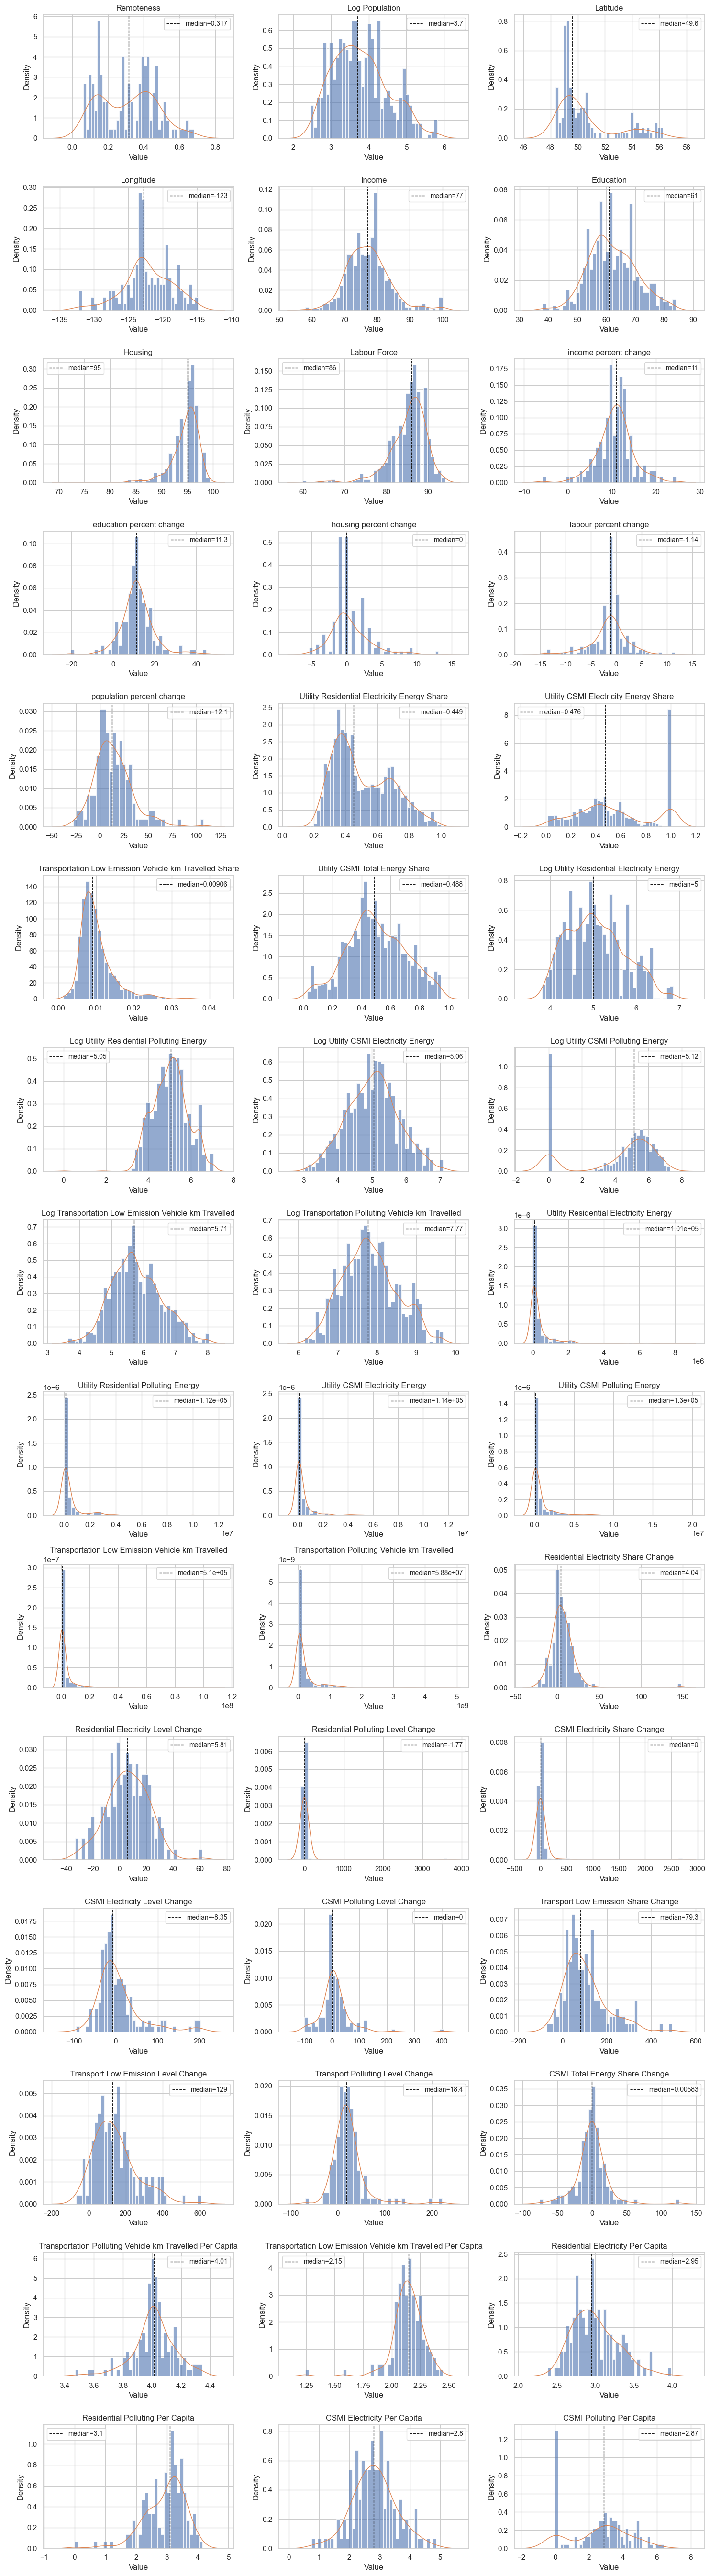

In [118]:
# Plot histograms for change metrics (paste into your notebook)
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

change_metrics = [
    'Residential_Electricity_Share_Change',
    'Residential_Electricity_Level_Change',
    'Residential_Polluting_Level_Change',
    'CSMI_Electricity_Share_Change',
    'CSMI_Electricity_Level_Change',
    'CSMI_Polluting_Level_Change',
    'Transport_Low_Emission_Share_Change',
    'Transport_Low_Emission_Level_Change',
    'Transport_Polluting_Level_Change',
    'CSMI_Total_Energy_Share_Change',
]
features_to_use = [
    # Context
    'Remoteness',
    'Log_Population',
    'Latitude',
    'Longitude',
    
    # Wellbeing baseline
    'Income', 'Education', 'Housing', 'Labour_Force', #'CWB',
    
    # Wellbeing trajectories
    'income_percent_change', 'education_percent_change', 
    'housing_percent_change', 'labour_percent_change', 
    'population_percent_change',
    
    # Low-emissions energy shares baseline
    'Utility_Residential_Electricity_Energy_Share',
    'Utility_CSMI_Electricity_Energy_Share',
    'Transportation_Low_Emission_Vehicle_km_Travelled_Share',
    
    # Economic structure baseline
    'Utility_CSMI_Total_Energy_Share', #this is share on total utility enery, not including tranport
    
    # Energy sources baseline (log-transformed)
    'Log_Utility_Residential_Electricity_Energy',
    'Log_Utility_Residential_Polluting_Energy',
    'Log_Utility_CSMI_Electricity_Energy',
    'Log_Utility_CSMI_Polluting_Energy',
    'Log_Transportation_Low_Emission_Vehicle_km_Travelled',
    'Log_Transportation_Polluting_Vehicle_km_Travelled',
    
    # Energy sources baseline totals
    'Utility_Residential_Electricity_Energy',
    'Utility_Residential_Polluting_Energy',
    'Utility_CSMI_Electricity_Energy',
    'Utility_CSMI_Polluting_Energy',
    'Transportation_Low_Emission_Vehicle_km_Travelled',
    'Transportation_Polluting_Vehicle_km_Travelled',

    
    # Energy transition trajectories
    'Residential_Electricity_Share_Change',
    'Residential_Electricity_Level_Change',
    'Residential_Polluting_Level_Change',
    'CSMI_Electricity_Share_Change',
    'CSMI_Electricity_Level_Change',
    'CSMI_Polluting_Level_Change',
    'Transport_Low_Emission_Share_Change',
    'Transport_Low_Emission_Level_Change',
    'Transport_Polluting_Level_Change',
    
    # Economic transition trajectories
    'CSMI_Total_Energy_Share_Change',
    
    # Per capita values
    'Transportation_Polluting_Vehicle_km_Travelled_Per_Capita',
    'Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita',
    
    'Residential_Electricity_Per_Capita',
    'Residential_Polluting_Per_Capita',
    'CSMI_Electricity_Per_Capita',
    'CSMI_Polluting_Per_Capita'
]

# Keep only rows for the change metrics requested
df = tidy_all_data[tidy_all_data['Metric'].isin(features_to_use)].copy()
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

# remove infinities and extremely large sentinels -- convert to NaN so they are dropped
df['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)

# plotting layout
n = len(features_to_use)
ncols = 3
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.6 * nrows))
axes = axes.flatten()

for ax, metric in zip(axes, features_to_use):
    vals = df.loc[df['Metric'] == metric, 'Value'].dropna()
    if vals.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(metric)
        ax.axis('off')
        continue

    # Plot histogram + KDE
    sns.histplot(vals, bins=40, stat='density', ax=ax, color='C0', edgecolor=None, alpha=0.6)
    try:
        sns.kdeplot(vals, ax=ax, color='C1', lw=1)
    except Exception:
        pass

    # annotate some summary stats
    med = vals.median()
    mean = vals.mean()
    q1, q3 = vals.quantile([0.25, 0.75])
    ax.axvline(med, color='k', linestyle='--', lw=1, label=f'median={med:.3g}')
    ax.set_title(metric.replace('_', ' '))
    ax.legend(fontsize='small')

# hide unused axes
for i in range(n, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
# optional: save figure
#out_path = 'reports/figures/change_metrics_histograms.png'
#plt.savefig(out_path, dpi=200, bbox_inches='tight')
#print(f"Saved histogram figure to: {out_path}")
plt.show()

In [119]:
import numpy as np
import pandas as pd

# replace with your change-metrics list (or keep the one below)
change_metrics = [
    'Residential_Electricity_Share_Change',
    'Residential_Electricity_Level_Change',
    'Residential_Polluting_Level_Change',
    'CSMI_Electricity_Share_Change',
    'CSMI_Electricity_Level_Change',
    'CSMI_Polluting_Level_Change',
    'Transport_Low_Emission_Share_Change',
    'Transport_Low_Emission_Level_Change',
    'Transport_Polluting_Level_Change',
    'CSMI_Total_Energy_Share_Change',
    
    
]

# filter to the requested change metrics
df = tidy_all_data[tidy_all_data['Metric'].isin(change_metrics)].copy()
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

# drop infinite values and keep NaNs to be explicit
df['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)

# compute per-metric mean and std (skip metrics with insufficient data)
grp = df.groupby('Metric')['Value']
df['mean'] = grp.transform('mean')
df['std'] = grp.transform('std')
df['median'] = grp.transform('median')

# avoid division by zero: mark std==0 as non-outlier
df['zscore'] = (df['Value'] - df['mean']) / df['std']
df.loc[df['std'] == 0, 'zscore'] = np.nan

# flag outliers: absolute z-score > 3
df['is_outlier_3sd'] = df['zscore'].abs() > 3

# produce summary of results
summary = df.groupby('Metric').agg(
    n_total=('Value','size'),
    n_nonnull=('Value','count'),
    n_outliers=('is_outlier_3sd','sum'),
    mean=('mean','first'),
    median=('median','first'),
    std=('std','first')
).reset_index()

print("Outlier summary per metric:")
display(summary)

# list of outlier rows (municipality, year, value, zscore)
outliers = df[df['is_outlier_3sd']].sort_values(['Metric','zscore'], ascending=[True, False])
print(f"\nTotal outlier rows found: {len(outliers)}")
display(outliers[['Municipality_Name','Year','Metric','Value','zscore']].reset_index(drop=True))


Outlier summary per metric:


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_81693/470100027.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Value'].replace([np.inf, -np.inf], np.nan, inplace=True)


,Metric,n_total,n_nonnull,n_outliers,mean,median,std
0,CSMI_Electricity_Level_Change,145,145,5,6.373173,-8.351670,52.122852
1,CSMI_Electricity_Share_Change,145,145,1,28.796868,0.000000,234.217239
2,CSMI_Polluting_Level_Change,145,145,2,10.086209,0.000000,55.343088
3,CSMI_Total_Energy_Share_Change,145,145,2,-0.612222,0.005827,21.685186
4,Residential_Electricity_Level_Change,145,145,1,6.193887,5.814418,15.431901
5,Residential_Electricity_Share_Change,145,145,1,6.111496,4.037335,15.925015
6,Residential_Polluting_Level_Change,145,145,1,21.142749,-1.772876,302.786439
7,Transport_Low_Emission_Level_Change,145,145,2,143.463191,128.833523,116.281531
8,Transport_Low_Emission_Share_Change,145,145,2,102.710865,79.264962,96.596766
9,Transport_Polluting_Level_Change,145,145,3,22.401409,18.359591,34.370390



Total outlier rows found: 20


,Municipality_Name,Year,Metric,Value,zscore
0,Princeton,2021,CSMI_Electricity_Level_Change,202.452955,3.761877
1,Kaslo,2021,CSMI_Electricity_Level_Change,195.722415,3.632749
2,Oliver,2021,CSMI_Electricity_Level_Change,193.593415,3.591903
3,Creston,2021,CSMI_Electricity_Level_Change,188.690671,3.497842
4,Penticton,2021,CSMI_Electricity_Level_Change,177.792501,3.288756
5,Warfield,2021,CSMI_Electricity_Share_Change,2705.176830,11.426913
6,Burns Lake,2021,CSMI_Polluting_Level_Change,405.258969,7.140418
7,Taylor,2021,CSMI_Polluting_Level_Change,222.261259,3.833813
8,Kaslo,2021,CSMI_Total_Energy_Share_Change,125.123657,5.798239
9,Warfield,2021,CSMI_Total_Energy_Share_Change,-75.356208,-3.446776


In [120]:
#print the list of outlier municipalities
outlier_municipalities = outliers['Municipality_Name'].unique()
print(outlier_municipalities)

['Princeton' 'Kaslo' 'Oliver' 'Creston' 'Penticton' 'Warfield'
 'Burns Lake' 'Taylor' 'Langford' 'Telkwa' 'Highlands' 'Squamish'
 'Burnaby' 'Richmond' 'Invermere' 'Cache Creek']


Typologies 

We want to cluster municipalities to create municipal typologies because policymakers cannot create 161 different policies. If we want to create equitable energy transition policies, it would be helpful to think of variables that highlight inequities and different challenges across different municipalities 

In this case, remoteness index is a highly relevant variable 

Whether wellbeing is trending upward or downward is also highly relevant -> find regression slope and R2 for each variable 

Whether industry or residences drive emissions, and whether natural gas or electricity drives total emissions
* Measured by percent of total emissions from industry and residential sector 
* Measured by correlation of percent changes in total emissions and residential vs. Industrial sector in the past 20 years 

Whether changes in energy consumption or changes in emissions factors drive changes in emissions
* Measured by correlation of percent change in yearly emissions factors and percent changes in yearly total emissions vs. correlation of percent changes in total energy consumption and percent changes in total emissions

Whether the local government has a climate action plan and if not why not (e.g. lack of funding, etc.) important 

Baseline emissions per capita 

Found 0 duplicate rows:


,Municipality_Name,Metric,Value


No missing values found in X.
PCA reduced to 6 components to explain 80% variance
Silhouette scores by k: {2: np.float64(0.22539335851765052), 3: np.float64(0.169356038921299), 4: np.float64(0.17414979533487623), 5: np.float64(0.1987533846079961), 6: np.float64(0.22373609824694118), 7: np.float64(0.23647315843178807), 8: np.float64(0.2207520285551909), 9: np.float64(0.20389800611128894), 10: np.float64(0.21315933783621085), 11: np.float64(0.2183580820894769), 12: np.float64(0.20242580510080216), 13: np.float64(0.21570084829939085), 14: np.float64(0.20676864468030257), 15: np.float64(0.20708368487069115), 16: np.float64(0.19321572974165813), 17: np.float64(0.2156304789273312), 18: np.float64(0.19437324583007404), 19: np.float64(0.2093608891164126), 20: np.float64(0.2109623690453829), 21: np.float64(0.20812000455088867), 22: np.float64(0.22087173857244036), 23: np.float64(0.21407886010728994), 24: np.float64(0.2032784402919326), 25: np.float64(0.2102188475938603), 26: np.float64(0.214533

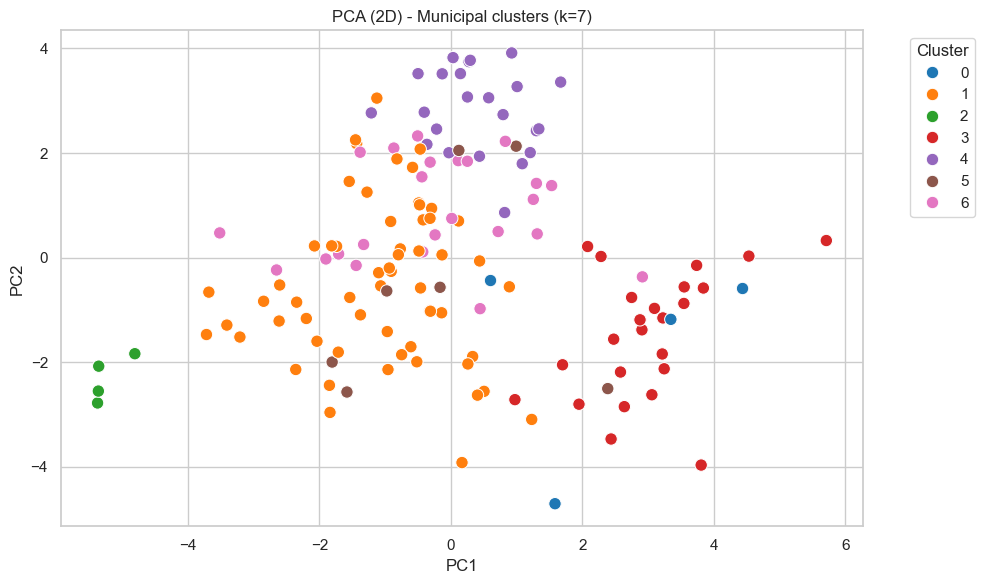

,Remoteness,Population,Latitude,Utility_Residential_Electricity_Energy_Share,Utility_CSMI_Electricity_Energy_Share,CSMI_Electricity_Level_Change,Transport_Low_Emission_Share_Change,Transport_Low_Emission_Level_Change,Transport_Polluting_Level_Change,CSMI_Total_Energy_Share_Change,Transportation_Polluting_Vehicle_km_Travelled_Per_Capita,Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita,Residential_Electricity_Per_Capita,Residential_Polluting_Per_Capita,CSMI_Electricity_Per_Capita,CSMI_Polluting_Per_Capita
Cluster,,,,,,,,,,,,,,,,
0,0.42,818.25,51.88,0.72,0.92,-34.22,77.74,36.01,-17.06,-13.68,3.66,1.62,3.37,2.41,2.40,0.70
1,0.21,27193.24,49.34,0.48,0.43,-3.13,141.59,183.65,18.57,-3.20,3.97,2.18,2.94,3.00,2.37,2.79
2,0.07,422408.00,49.19,0.41,0.36,-9.70,394.88,362.14,-8.91,-1.44,3.73,2.24,2.58,2.91,2.67,3.23
3,0.48,1614.88,51.57,0.77,0.96,-14.24,56.92,82.69,15.18,-7.64,4.06,2.12,3.35,2.12,2.98,0.16
4,0.44,8510.39,54.23,0.33,0.29,-14.83,36.03,58.37,17.25,-4.63,4.15,2.15,2.89,3.57,3.22,4.21
5,0.27,13682.43,49.74,0.55,0.52,-6.87,69.48,294.60,134.79,-7.71,4.02,2.12,3.01,2.81,2.72,2.51
6,0.30,31553.25,49.43,0.43,0.50,83.98,81.97,124.39,23.00,21.00,4.06,2.14,2.89,3.15,3.53,3.42


,Remoteness,Population,Latitude,Utility_Residential_Electricity_Energy_Share,Utility_CSMI_Electricity_Energy_Share,CSMI_Electricity_Level_Change,Transport_Low_Emission_Share_Change,Transport_Low_Emission_Level_Change,Transport_Polluting_Level_Change,CSMI_Total_Energy_Share_Change,Transportation_Polluting_Vehicle_km_Travelled_Per_Capita,Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita,Residential_Electricity_Per_Capita,Residential_Polluting_Per_Capita,CSMI_Electricity_Per_Capita,CSMI_Polluting_Per_Capita
Cluster,,,,,,,,,,,,,,,,
0,0.22,449.36,2.23,0.14,0.16,20.36,127.45,130.34,35.82,32.60,0.16,0.28,0.21,0.53,1.16,1.39
1,0.10,33645.50,0.62,0.16,0.23,29.80,82.73,89.56,18.22,15.34,0.10,0.10,0.28,0.58,0.49,1.33
2,0.02,226557.60,0.07,0.05,0.04,12.92,86.68,123.15,19.72,5.31,0.11,0.07,0.06,0.13,0.26,0.45
3,0.13,1180.65,2.15,0.10,0.10,29.13,66.97,91.61,17.48,15.48,0.08,0.10,0.21,0.67,0.67,0.48
4,0.05,15820.68,1.58,0.08,0.14,38.14,34.98,43.75,21.42,27.30,0.12,0.12,0.15,0.28,0.59,0.92
5,0.12,16296.96,0.83,0.16,0.22,22.68,79.60,192.80,55.30,11.83,0.10,0.12,0.22,0.50,0.49,1.22
6,0.11,51387.07,0.57,0.08,0.26,67.27,67.10,86.13,19.87,24.53,0.10,0.08,0.18,0.22,0.59,1.38


In [121]:
# clustering municipalities based on PCA of selected metrics

# --- PCA + clustering pipeline (add / run in a new cell) ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mstats

# choose baseline year and metric list (edit to taste)
BASE_YEAR = 2021

features_to_use = [
    # Context
    'Remoteness', #biomodal
    'Population',
    'Latitude', #biomodal
    #'Longitude',
    
    # Wellbeing baseline
    #'Income', 'Education', 'Housing', 'Labour_Force', #'CWB',
    
    # Wellbeing trajectories
    #'income_percent_change', 'education_percent_change', 
    #'housing_percent_change', 'labour_percent_change', 
    #'population_percent_change',
    
    # Low-emissions energy shares baseline
    'Utility_Residential_Electricity_Energy_Share',
    'Utility_CSMI_Electricity_Energy_Share', #biomodal
    #'Transportation_Low_Emission_Vehicle_km_Travelled_Share',
    
    # Economic structure baseline
    #'Utility_CSMI_Total_Energy_Share', #this is share on total utility enery, not including tranport
    #'Transportation_CSMI_Total_Energy_Share',
    
    # Emissions factors baselinec-> redundant as shares can capture this already
    #'Residential_Emissions_Factor',
    #'CSMI_Emissions_Factor',
    #'Transportation_Emissions_Factor',
    
    # Energy sources baseline (log-transformed)
    #'Log_Utility_Residential_Electricity_Energy',
    #'Log_Utility_Residential_Polluting_Energy',
    #'Log_Utility_CSMI_Electricity_Energy',
    #'Log_Utility_CSMI_Polluting_Energy', #biomodal
    #'Log_Transportation_Low_Emission_Vehicle_km_Travelled',
    #'Log_Transportation_Polluting_Vehicle_km_Travelled',
    
    # Don't use as log creates clearer separation between clusters
    # Energy sources baseline totals
    #'Utility_Residential_Electricity_Energy',
    #'Utility_Residential_Polluting_Energy',
    #'Utility_CSMI_Electricity_Energy',
    #'Utility_CSMI_Polluting_Energy',
    #'Transportation_Low_Emission_Vehicle_km_Travelled',
    #'Transportation_Polluting_Vehicle_km_Travelled',

    
    # Energy transition trajectories
    #'Residential_Electricity_Share_Change',
    #'Residential_Electricity_Level_Change',
    #'Residential_Polluting_Level_Change',
    #'CSMI_Electricity_Share_Change',
    'CSMI_Electricity_Level_Change',
    #'CSMI_Polluting_Level_Change',
    'Transport_Low_Emission_Share_Change',
    'Transport_Low_Emission_Level_Change',
    'Transport_Polluting_Level_Change',
    
    # Economic transition trajectories
    'CSMI_Total_Energy_Share_Change',
    
    # Per capita values
    'Transportation_Polluting_Vehicle_km_Travelled_Per_Capita',
    'Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita',
    
    'Residential_Electricity_Per_Capita',
    'Residential_Polluting_Per_Capita',
    'CSMI_Electricity_Per_Capita',
    'CSMI_Polluting_Per_Capita'
]

# build wide feature matrix for BASE_YEAR
df_feat = tidy_all_data.loc[tidy_all_data['Year'] == BASE_YEAR, ['Municipality_Name','Metric','Value']].copy()
# Find duplicates
duplicates = df_feat[df_feat.duplicated(subset=['Municipality_Name', 'Metric'], keep=False)]
print(f"Found {len(duplicates)} duplicate rows:")
display(duplicates.sort_values(['Municipality_Name', 'Metric']))

df_wide = df_feat.pivot(index='Municipality_Name', columns='Metric', values='Value')


# ensure chosen features are present, add missing as NaN
for f in features_to_use:
    if f not in df_wide.columns:
        df_wide[f] = np.nan

# select only desired columns and drop rows with no data at all
X = df_wide[features_to_use].copy()

# diagnostic: find missing values BEFORE scaling/PCA (PCA/Scaler do not accept NaN)
nan_counts = X.isna().sum()
if nan_counts.sum() > 0:
    print("Missing values present. Counts per feature:\n", nan_counts[nan_counts > 0])
    nan_rows = X[X.isna().any(axis=1)]
    print("\nCommunities with missing data (total {}):".format(len(nan_rows)))
    for idx, row in nan_rows.iterrows():
        missing_feats = row[row.isna()].index.tolist()
        print(f" - {idx}: missing {missing_feats}")
    # show some raw tidy rows for the first few affected communities to investigate source
    sample_comm = list(nan_rows.index)[:8]
    print("\nSample raw tidy_all_data rows for inspection:")
    display(tidy_all_data[tidy_all_data['Municipality_Name'].isin(sample_comm)].sort_values(['Municipality_Name','Year','Metric']).head(40))
else:
    print("No missing values found in X.")

# Option A (recommended for exploration): keep original X, but use a dropna copy for clustering so PCA runs
X_for_clustering = X.dropna(how='any')          # drop municipalities with any missing selected features
#print(f"\nUsing {len(X_for_clustering)} municipalities for clustering (dropped {len(X)-len(X_for_clustering)} with NaNs).")

# Option B (alternate) you can choose to impute, e.g. small-year forward/backfill per municipality or leave median:
# X_for_clustering = X.fillna(X.median())

#def winsorize_column(series, limits=(0.01, 0.01)):
#    """Cap values at 1rst and 99th percentile"""
#    return pd.Series(mstats.winsorize(series, limits=limits), index=series.index)

# Apply to change metrics before clustering
#for col in change_metrics:
#    X_for_clustering[col] = winsorize_column(X_for_clustering[col])

# Standardize (use X_for_clustering for the pipeline)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_for_clustering)
# ...continue with PCA/KMeans but remember to use X_for_clustering.index when assembling results
# ...existing code...

# PCA: keep components that explain 90% variance for clustering, but compute 2D for plotting
pca80 = PCA(n_components=0.80, svd_solver='full')
X_pca_80 = pca80.fit_transform(X_scaled)
print(f"PCA reduced to {X_pca_80.shape[1]} components to explain 80% variance")

pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

pca_full = PCA(n_components=6)
X_pca_4 = pca_full.fit_transform(X_scaled)
X_pca_4_standardized = StandardScaler().fit_transform(X_pca_4)  # Equal weighting

# choose number of clusters with silhouette (k=2..8)
best_k, best_score = None, -1
scores = {}
for k in range(2, 30):
    km = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = km.fit_predict(X_pca_4_standardized)
    score = silhouette_score(X_pca_4_standardized, labels)
    scores[k] = score
    if score > best_score:
        best_score = score
        best_k = k

print("Silhouette scores by k:", scores)
print("Best k:", best_k, "score:", best_score)

# Fit final KMeans on PCA space
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=100)
labels_final = kmeans_final.fit_predict(X_pca_4_standardized)

# assemble results dataframe and save
clusters_df = pd.DataFrame({
    'Municipality_Name': X.index,
    'Cluster': labels_final
}).set_index('Municipality_Name')

# merge back some original features for inspection
clustered = X.merge(clusters_df, left_index=True, right_index=True)

# save CSV
clustered.reset_index().to_csv('../data/processed/municipality_clusters_baseline2021.csv', index=False)

# Plot PCA 2D scatter with cluster labels
plt.figure(figsize=(10,6))
palette = sns.color_palette('tab10', n_colors=best_k)
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=labels_final, palette=palette, s=80, legend='full')
plt.title(f'PCA (2D) - Municipal clusters (k={best_k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# Quick summary per cluster
display(clustered.groupby('Cluster').mean().round(2))
#save means in a csv
clustered.groupby('Cluster').mean().round(2).to_csv('../data/processed/municipality_clusters_feature_means.csv')

#display standard deviation per cluster
display(clustered.groupby('Cluster').std().round(2))
clustered.groupby('Cluster').std().round(2).to_csv('../data/processed/municipality_clusters_feature_std.csv')


In [122]:
# Plot clusters on a map
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(clustered['Longitude'], clustered['Latitude'], c=clustered['Cluster'], cmap='tab10', s=50)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Clusters by geographic location')
plt.colorbar(label='Cluster')
plt.show()

KeyError: 'Longitude'

<Figure size 1000x800 with 0 Axes>

In [ ]:
# print community names with nan values in any of the selected features
nan_communities = X[X.isna().any(axis=1)].index.tolist()
print("Communities with missing data in selected features:")
for comm in nan_communities:
    print(" -", comm)


Communities with missing data in selected features:


Explained variance (first 6 PCs):
PC1    0.291
PC2    0.200
PC3    0.117
PC4    0.078
PC5    0.064
PC6    0.048
dtype: float64

Top contributors to PC1 (absolute loading):


Metric
Remoteness                                                     0.397622
Log_Population                                                 0.390339
Log_Utility_Residential_Electricity_Energy                     0.385067
Transport_Low_Emission_Share_Change                            0.370506
Transport_Low_Emission_Level_Change                            0.352176
Latitude                                                       0.284771
Transportation_Polluting_Vehicle_km_Travelled_Per_Capita       0.267939
Residential_Electricity_Per_Capita                             0.186055
CSMI_Electricity_Per_Capita                                    0.172851
Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita    0.166710
Name: PC1, dtype: float64


Top contributors to PC2 (absolute loading):


Metric
Utility_Residential_Electricity_Energy_Share                0.499471
Residential_Polluting_Per_Capita                            0.460391
Utility_CSMI_Electricity_Energy_Share                       0.434729
Residential_Electricity_Per_Capita                          0.372752
CSMI_Polluting_Per_Capita                                   0.340789
Latitude                                                    0.170343
Transportation_Polluting_Vehicle_km_Travelled_Per_Capita    0.161737
CSMI_Electricity_Per_Capita                                 0.101761
Log_Population                                              0.095387
Transport_Low_Emission_Level_Change                         0.091305
Name: PC2, dtype: float64

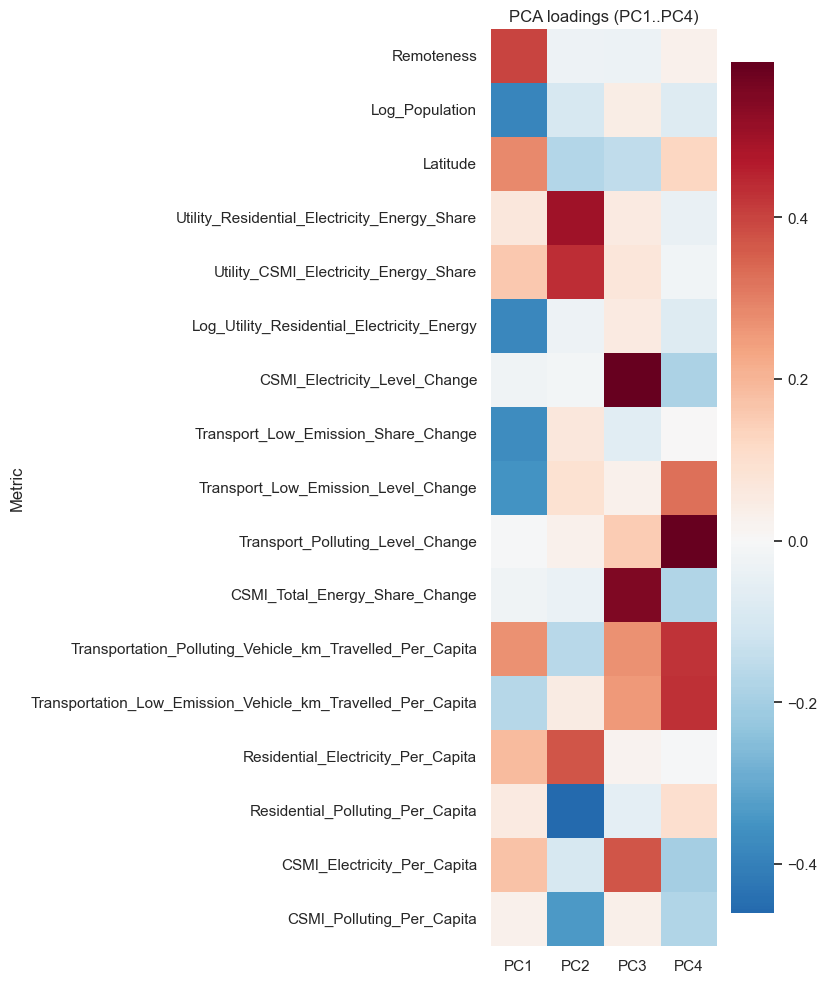


Cluster centroids (approx, original units):


Metric,Remoteness,Log_Population,Latitude,Utility_Residential_Electricity_Energy_Share,Utility_CSMI_Electricity_Energy_Share,Log_Utility_Residential_Electricity_Energy,CSMI_Electricity_Level_Change,Transport_Low_Emission_Share_Change,Transport_Low_Emission_Level_Change,Transport_Polluting_Level_Change,CSMI_Total_Energy_Share_Change,Transportation_Polluting_Vehicle_km_Travelled_Per_Capita,Transportation_Low_Emission_Vehicle_km_Travelled_Per_Capita,Residential_Electricity_Per_Capita,Residential_Polluting_Per_Capita,CSMI_Electricity_Per_Capita,CSMI_Polluting_Per_Capita
Cluster_0,0.405,3.601,52.593,0.326,0.282,4.808,-15.566,39.965,69.860,24.181,-6.378,13402.719,132.683,16.304,34.876,23.006,101.043
Cluster_1,0.209,3.970,49.314,0.567,0.530,5.292,7.709,125.605,208.606,39.165,0.357,10056.025,159.896,21.830,18.134,12.651,27.312
Cluster_2,0.121,4.944,49.162,0.439,0.374,6.095,-2.746,235.188,257.938,7.693,-1.601,7371.709,159.122,14.407,19.437,12.722,25.768
Cluster_3,0.484,3.033,51.714,0.761,0.957,4.474,-17.317,59.868,74.090,9.433,-8.534,10572.618,120.709,28.250,9.337,22.503,0.922
Cluster_4,0.351,3.494,49.413,0.446,0.565,4.753,107.993,55.877,89.014,21.241,25.211,12886.149,139.192,18.368,23.204,47.339,58.612



Top features by ANOVA F (difference across clusters):


,F,p
Remoteness,57.659,0.0
Utility_CSMI_Electricity_Energy_Share,50.312,0.0
Utility_Residential_Electricity_Energy_Share,48.104,0.0
Log_Population,35.549,0.0
CSMI_Electricity_Level_Change,34.784,0.0
Residential_Polluting_Per_Capita,33.466,0.0
Log_Utility_Residential_Electricity_Energy,32.286,0.0
Residential_Electricity_Per_Capita,29.208,0.0
Transportation_Polluting_Vehicle_km_Travelled_Per_Capita,25.423,0.0
Latitude,22.764,0.0



Top features by permutation importance (random forest predicting clusters):


Metric
Transport_Polluting_Level_Change              0.0225
Transport_Low_Emission_Level_Change           0.0103
CSMI_Electricity_Per_Capita                   0.0087
Residential_Electricity_Per_Capita            0.0046
Remoteness                                    0.0041
Log_Population                                0.0030
Log_Utility_Residential_Electricity_Energy    0.0000
CSMI_Electricity_Level_Change                 0.0000
Transport_Low_Emission_Share_Change           0.0000
Utility_CSMI_Electricity_Energy_Share         0.0000
dtype: float64

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_80807/3376060171.py:92: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


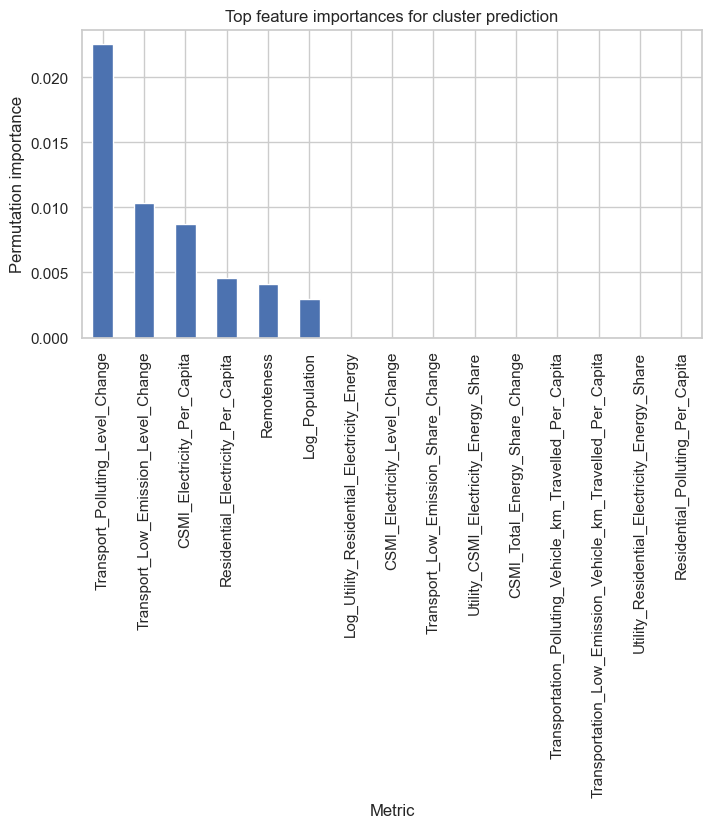


Interpretation hints:
- PCA loadings: large absolute loading = strong contributor to that PC.
- Explained variance: which PCs capture most variance.
- Cluster centroids: show how clusters differ on original features.
- ANOVA F: features with large F differ most across clusters (statistical).
- Permutation RF importance: features that best predict cluster membership (useful for interpretability).


In [ ]:
# ...existing code...

# Quick diagnostics: which input variables drive PCs and clusters
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from scipy.stats import f_oneway
from IPython.display import display

# try to reuse X, X_scaled and labels_final from the clustering cell; otherwise rebuild them
try:
    X_df = X.copy()
    Xs = X_scaled.copy()
    labels = labels_final.copy()
except NameError:
    # rebuild X (same logic used in clustering cell)
    df_feat = tidy_all_data.loc[tidy_all_data['Year'] == BASE_YEAR, ['Municipality_Name','Metric','Value']].copy()
    df_wide = df_feat.pivot(index='Municipality_Name', columns='Metric', values='Value')
    for f in features_to_use:
        if f not in df_wide.columns:
            df_wide[f] = np.nan
    X_df = df_wide[features_to_use].copy().fillna(df_wide.median())
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X_df)
    pca_tmp = PCA(n_components=min(len(features_to_use), Xs.shape[0]))
    Xp = pca_tmp.fit_transform(Xs)
    km_tmp = KMeans(n_clusters=3, random_state=42, n_init=10)  # fallback k
    labels = km_tmp.fit_predict(Xp)

# PCA loadings (full PCA on standardized inputs)
pca_full = PCA().fit(Xs)
loadings = pd.DataFrame(pca_full.components_.T,
                        index=X_df.columns,
                        columns=[f'PC{i+1}' for i in range(pca_full.components_.shape[0])])
explained = pd.Series(pca_full.explained_variance_ratio_, index=loadings.columns)

print("Explained variance (first 6 PCs):")
print(explained.head(6).round(3))

print("\nTop contributors to PC1 (absolute loading):")
display(loadings['PC1'].abs().sort_values(ascending=False).head(10))

print("\nTop contributors to PC2 (absolute loading):")
display(loadings['PC2'].abs().sort_values(ascending=False).head(10))

# Heatmap of loadings for first 4 PCs
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,10))
sns.heatmap(loadings.iloc[:, :4], cmap='RdBu_r', center=0, annot=False)
plt.title('PCA loadings (PC1..PC4)')
plt.tight_layout()
plt.show()

# Approximate cluster centroids in original units
# (inverse-transform centroids computed in PCA space -> scaled space -> original units)
pca_for_centroids = PCA(n_components=min(Xs.shape[1], Xs.shape[0])).fit(Xs)
Xp_full = pca_for_centroids.transform(Xs)
kmeans_refit = KMeans(n_clusters=len(np.unique(labels)), random_state=42, n_init=10).fit(Xp_full)
centroids_pca = kmeans_refit.cluster_centers_
centroids_scaled = pca_for_centroids.inverse_transform(centroids_pca)
centroids_orig = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_orig, columns=X_df.columns, index=[f'Cluster_{i}' for i in range(centroids_orig.shape[0])])
print("\nCluster centroids (approx, original units):")
display(centroids_df.round(3))

# Which features differ most across clusters? ANOVA F-statistic
f_stats = {}
for col in X_df.columns:
    groups = [X_df[col].values[labels == k] for k in np.unique(labels)]
    try:
        f, p = f_oneway(*groups)
    except Exception:
        f, p = np.nan, np.nan
    f_stats[col] = (f, p)
f_df = pd.DataFrame.from_dict(f_stats, orient='index', columns=['F', 'p']).sort_values('F', ascending=False)
print("\nTop features by ANOVA F (difference across clusters):")
display(f_df.head(10).round(3))

# Supervised check: how predictive each feature is of the cluster (permutation importance)
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
X_filled = X_df.fillna(X_df.median())
rf.fit(X_filled, labels)
perm = permutation_importance(rf, X_filled, labels, n_repeats=30, random_state=42, n_jobs=-1)
imp_df = pd.Series(perm.importances_mean, index=X_df.columns).sort_values(ascending=False)
print("\nTop features by permutation importance (random forest predicting clusters):")
display(imp_df.head(10).round(4))

plt.figure(figsize=(8,4))
imp_df.head(15).plot.bar()
plt.ylabel('Permutation importance')
plt.title('Top feature importances for cluster prediction')
plt.tight_layout()
plt.show()

# Guidance:
print("\nInterpretation hints:")
print("- PCA loadings: large absolute loading = strong contributor to that PC.")
print("- Explained variance: which PCs capture most variance.")
print("- Cluster centroids: show how clusters differ on original features.")
print("- ANOVA F: features with large F differ most across clusters (statistical).")
print("- Permutation RF importance: features that best predict cluster membership (useful for interpretability).")

# ...existing code...

In [ ]:
#plot the final analysis data with coordinates on a map of BC, with shapefile located in the raw dataset subfolder BC_Boundary as BC_Boundary.shp
import geopandas as gpd
# Load the shapefile for BC boundaries
bc_boundaries = gpd.read_file(os.path.join('..', 'data', 'raw', 'BC_Boundary', 'BC_Boundary.shp'))
# Convert the final analysis data with coordinates to a GeoDataFrame
final_analysis_gdf = gpd.GeoDataFrame(
    final_analysis_data_with_coords,
    geometry=gpd.points_from_xy(final_analysis_data_with_coords['Longitude'], final_analysis_data_with_coords['Latitude']),
    crs='EPSG:4326'  # WGS84 coordinate system
)

decoupling_colors = {
    'em<0, wel>0': 'green',
    'em>0, wel>0, wel>em': 'blue',
    'em>0, wel>0, wel<em': 'orange',
    'em<0, wel<0, abs(wel)<abs(em)': 'purple',
    'em<0, wel<0, abs(wel)>abs(em)': 'pink',
    'em>0, wel<0': 'red',
    'Other': 'black'  # Default color for any other cases
}


final_analysis_gdf['color'] = final_analysis_gdf['utility_emissions_decoupling_type'].map(decoupling_colors)

plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
#plot the map with legend showing each color based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=15, label='Communities')
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in decoupling_colors.items()]
plt.legend(handles=handles, title='Decoupling Type', loc='upper right')

plt.title('Communities in BC with Decoupling Types (utility emissions change (2007-2010 to 2017-2020) vs. wellbeing change (2011-2021))')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()

NameError: name 'final_analysis_data_with_coords' is not defined

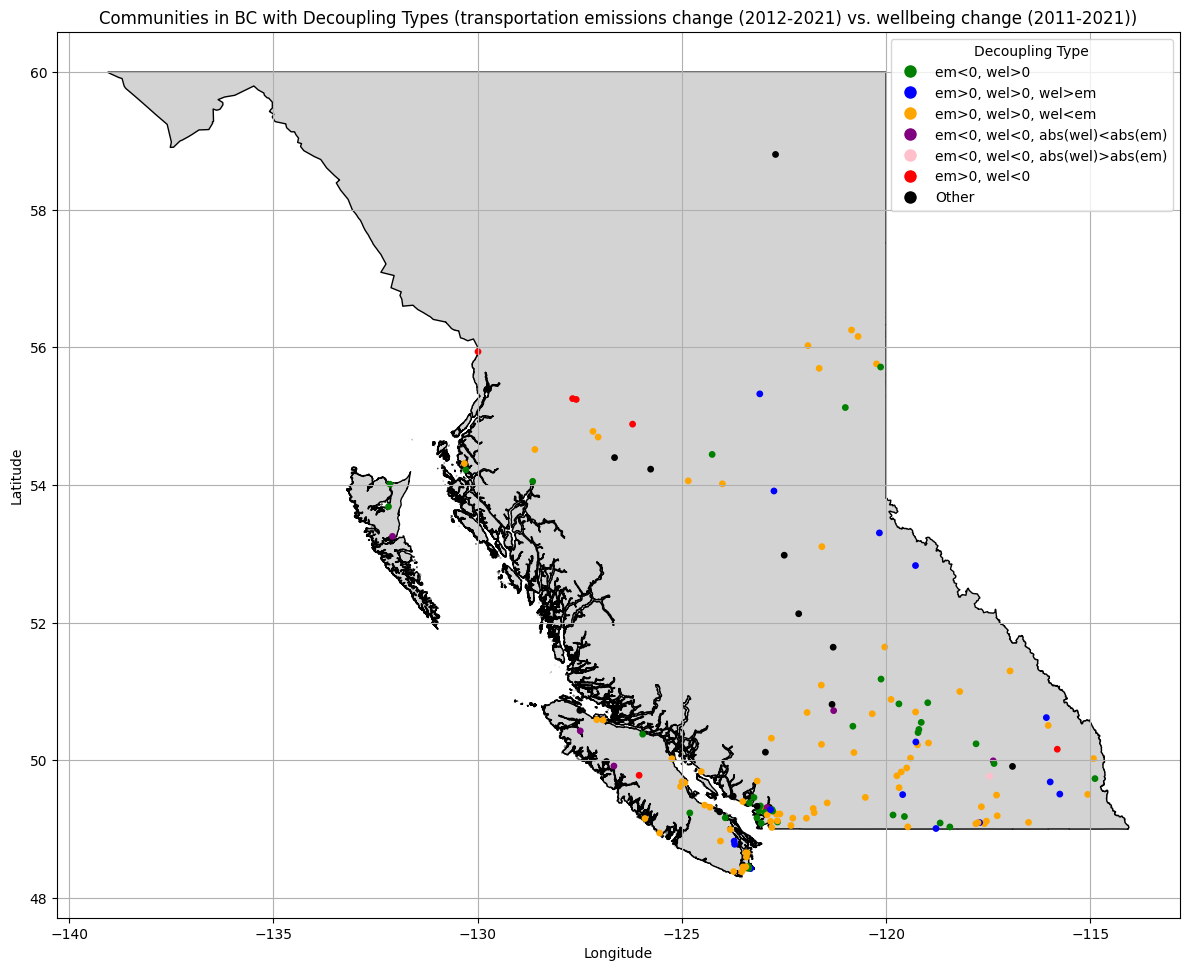

In [ ]:
final_analysis_gdf['color'] = final_analysis_gdf['transportation_emissions_decoupling_type'].map(decoupling_colors)

plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
#plot the map with legend showing each color based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=15, label='Communities')
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in decoupling_colors.items()]
plt.legend(handles=handles, title='Decoupling Type', loc='upper right')

plt.title('Communities in BC with Decoupling Types (transportation emissions change (2012-2021) vs. wellbeing change (2011-2021))')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Find name of communities in the worse case scenario of transportation emissions decoupling
worse_case_communities = final_analysis_gdf[final_analysis_gdf['transportation_emissions_decoupling_type'] == 'em>0, wel<0']
print(worse_case_communities['Municipality_Name'], worse_case_communities['transportation_emissions_percent_change'], worse_case_communities['cwb_percent_change'], worse_case_communities['Census Population 2011'])


12      Canal Flats
40       Gold River
43         Granisle
46         Hazelton
84     New Hazelton
135         Stewart
Name: Municipality_Name, dtype: object 12     29.087871
40     23.069154
43     11.529057
46     26.181138
84     34.634794
135     2.424826
Name: transportation_emissions_percent_change, dtype: float64 12    -2.531646
40    -2.500000
43    -1.408451
46    -2.298851
84    -1.333333
135   -1.265823
Name: cwb_percent_change, dtype: float64 12      715.0
40     1267.0
43      303.0
46      270.0
84      666.0
135     494.0
Name: Census Population 2011, dtype: float64


In [ ]:
# Find name of communities in the worse case scenario of utility emissions decoupling
worse_case_communities = final_analysis_gdf[final_analysis_gdf['utility_emissions_decoupling_type'] == 'em>0, wel<0']
print(worse_case_communities['Municipality_Name'], worse_case_communities['utility_emissions_percent_change'], worse_case_communities['cwb_percent_change'], worse_case_communities['Census Population 2011'])


6    Belcarra
Name: Municipality_Name, dtype: object 6    1.283684
Name: utility_emissions_percent_change, dtype: float64 6   -1.098901
Name: cwb_percent_change, dtype: float64 6    644.0
Name: Census Population 2011, dtype: float64


Next steps:
1) Manually create municipal shapefile boundaries for the municipalities that are missing from the data
2) Find if there is a way to include Northern Rockies
3) decide to include seachelt IDG or exclude it
4) add emissions of facilities outside of municipal boundaries to nearest municipality 




1) (DONE) map the coupling vs decoupling of municipalities across BC
    a) (DONE) find coordinates of each municipality
2) (DONE) add transportation emissions to building emissions and redo analysis
    a) show road networks in the map and power line networks as well
3) segregate analysis by sector (industry vs residential)
4) try using emissions from 2007 with wellbeing from 2006?
5) compare the disaggregated components of the wellbeing index (e.g. income vs. education vs. housing) with the emissions 
6) compare coupling/decoupling with climate action plans in LGCAP and with climate impacts to see which communities are most vulnerable
7) use actual census data (e.g. mean income value for community, education level) and make a random forest model that predicts coupling/decoupling using the census data?
8) see if the poorest communities that had lowest wellbeing to start with are the ones going through negative decoupling
9) subtract wellbeing change from emissions change to have a number that measures the extent of decoupling, or use taipa equation
